In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict

# Global styling for high-quality academic plots
plt.rcParams.update({
    'figure.dpi': 300,
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False
})

def plot_layer_metrics(
    file_path: str,
    layers: List[int],
    metrics: List[str],
    metric_labels: Dict[str, str],
    title: str,
    ylabel: str,
    output_file: str = None,
    column_template: str = "layer{layer}_{metric}"
):
    # Load data
    df = pd.read_csv(file_path)
    x = df['Step']

    # Define styles
    colors = ['#1b9e77', '#d95f02', '#7570b3']  # colorblind-safe
    line_styles = {'jumprelu': '-', 'singular_fisher': '--'}

    # Set up subplots
    fig, axes = plt.subplots(nrows=len(layers), ncols=1, figsize=(8, 2.5 * len(layers)), sharex=True)

    if len(layers) == 1:
        axes = [axes]  # Make iterable if one axis

    for i, layer in enumerate(layers):
        ax = axes[i]
        for j, metric in enumerate(metrics):
            base = column_template.format(layer=layer, metric=metric)
            col_min = f"{base}__MIN"
            col_max = f"{base}__MAX"

            if base not in df.columns:
                print(f"Warning: Missing column '{base}'")
                continue

            y = df[base]
            y_min = df[col_min] if col_min in df.columns else y
            y_max = df[col_max] if col_max in df.columns else y

            label = metric_labels.get(metric, metric)
            ax.plot(x, y, label=label,
                    color=colors[j % len(colors)],
                    linestyle=line_styles.get(metric, '-'),
                    linewidth=2)
            ax.fill_between(x, y_min, y_max, color=colors[j % len(colors)], alpha=0.15)

        ax.set_ylabel(f"Layer {layer}\n{ylabel}")
        ax.grid(True, linestyle='--', linewidth=0.5)

        if i == 0:
            ax.set_title(title)
        if i == len(layers) - 1:
            ax.set_xlabel('Training Step')

        ax.legend(loc='upper right')

    plt.tight_layout()
    if output_file:
        plt.savefig(output_file, bbox_inches='tight', format='pdf')
    plt.show()


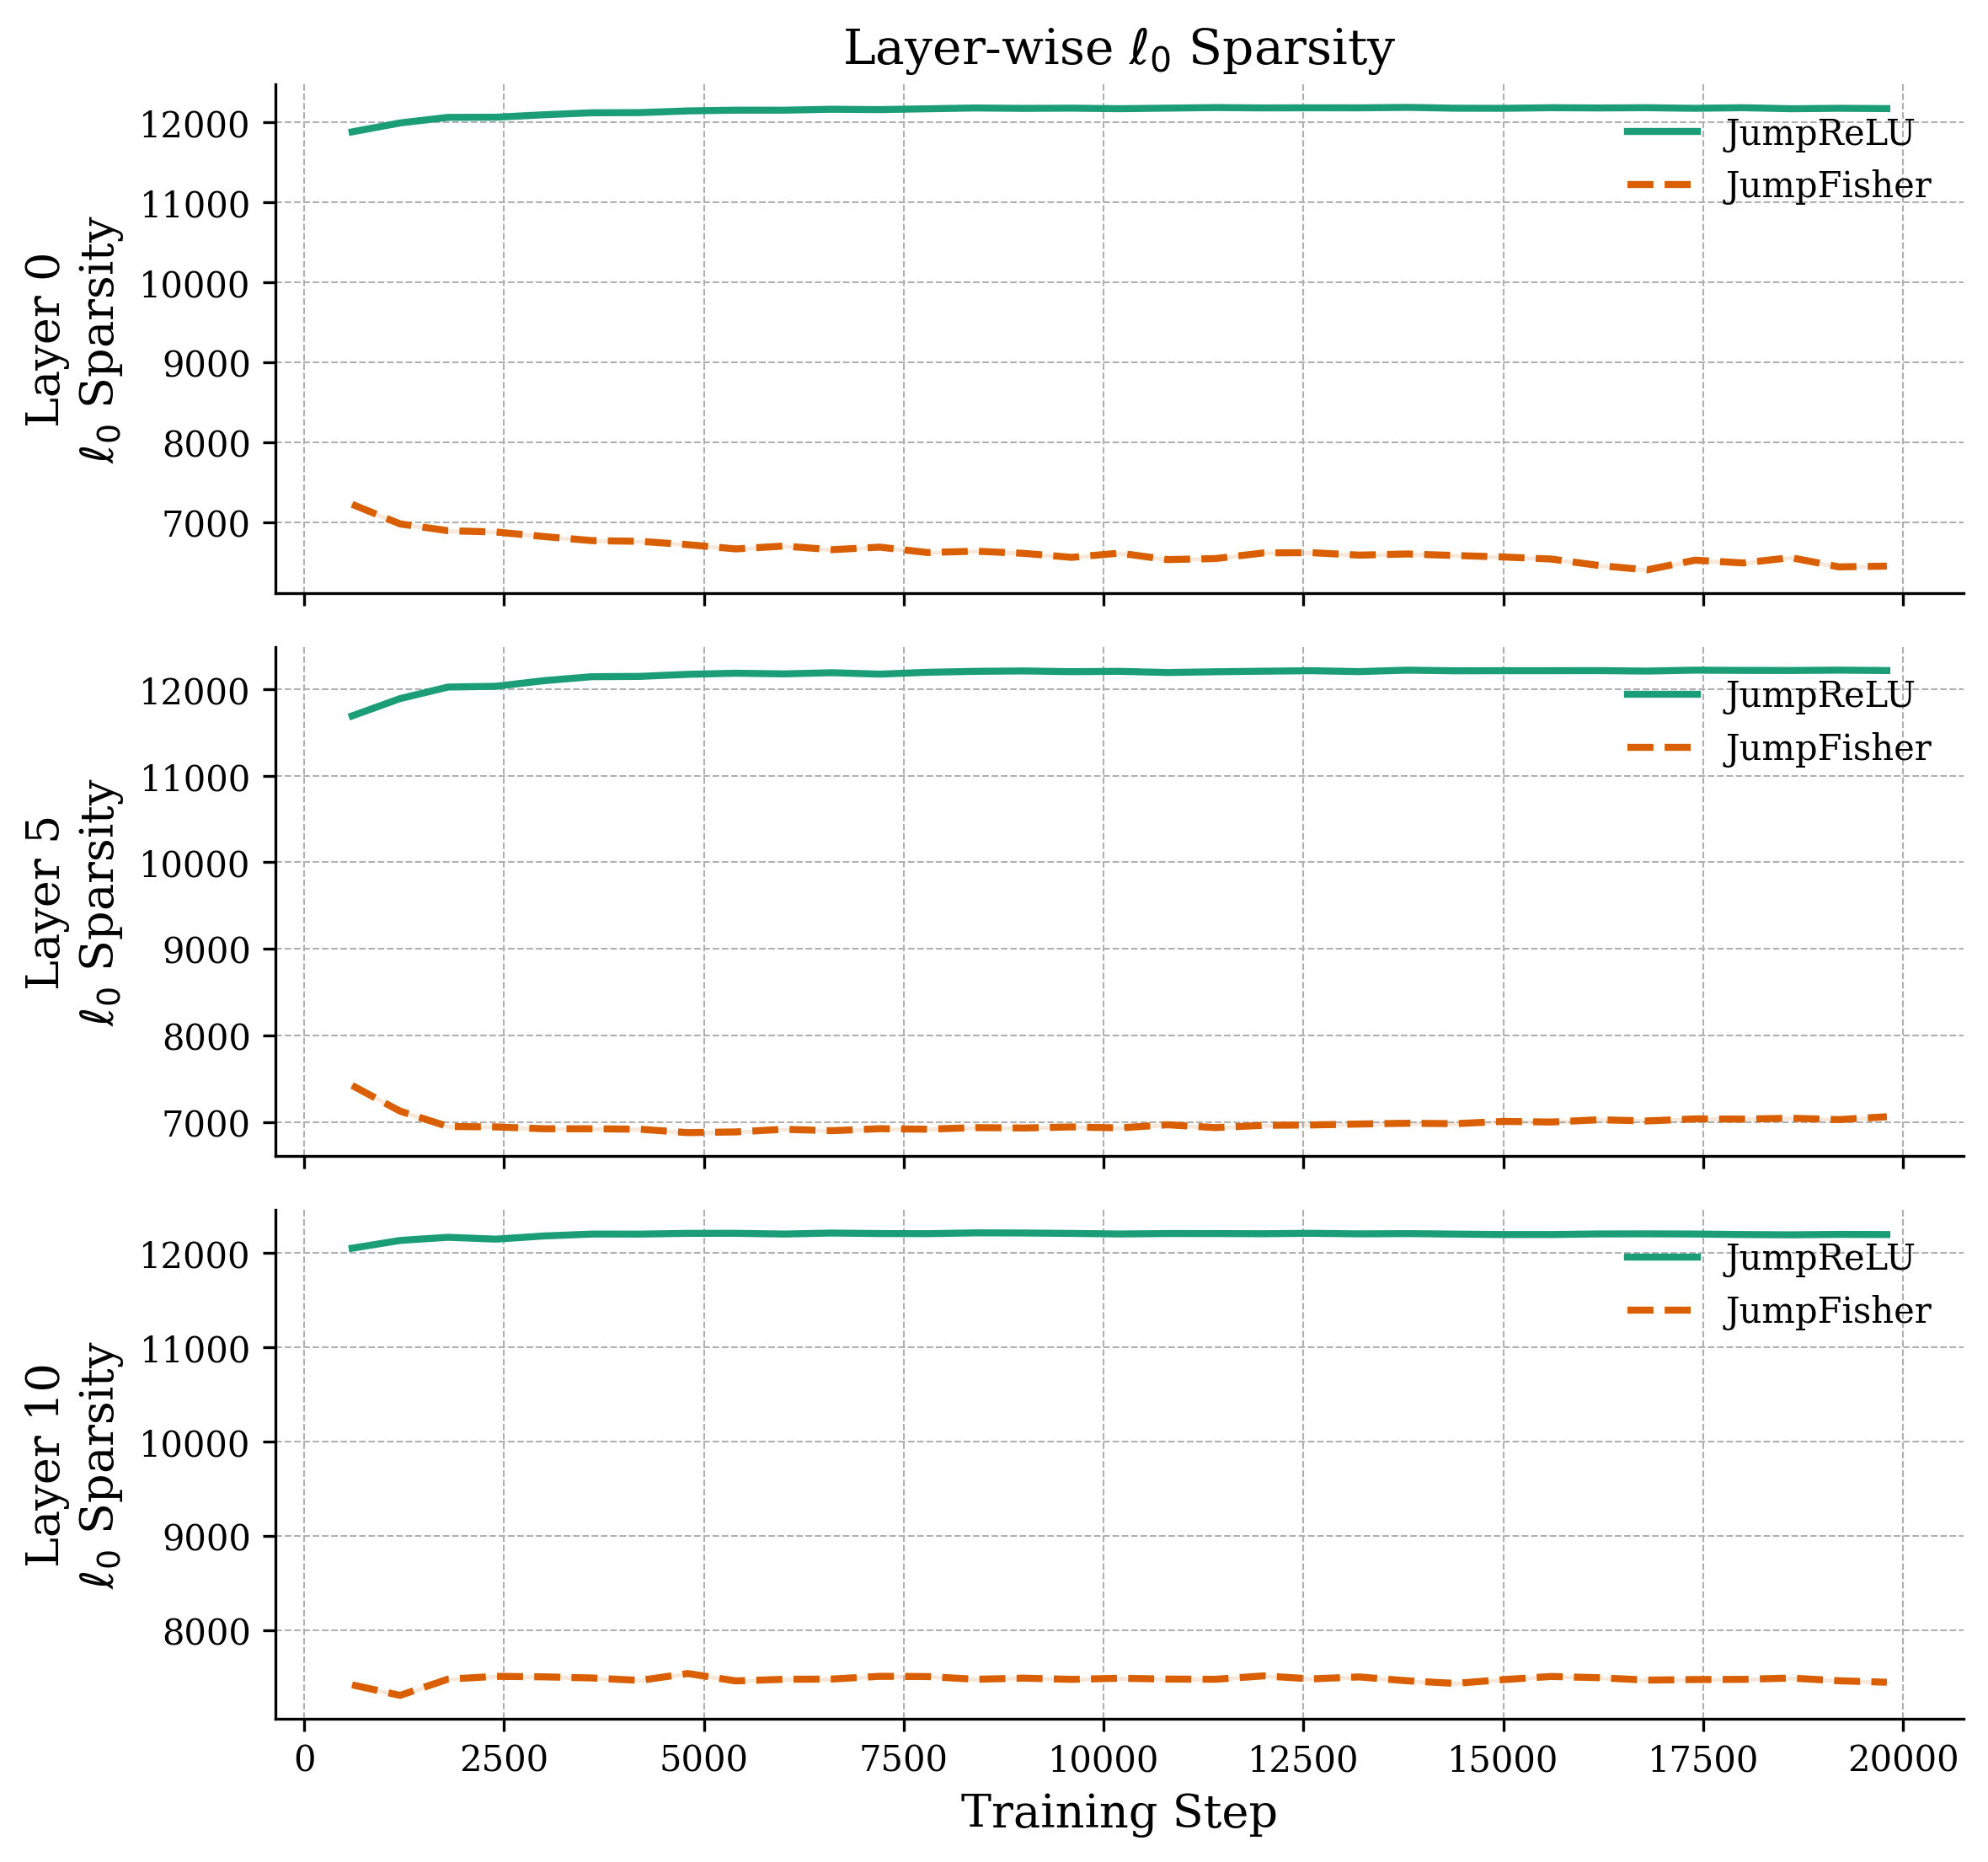

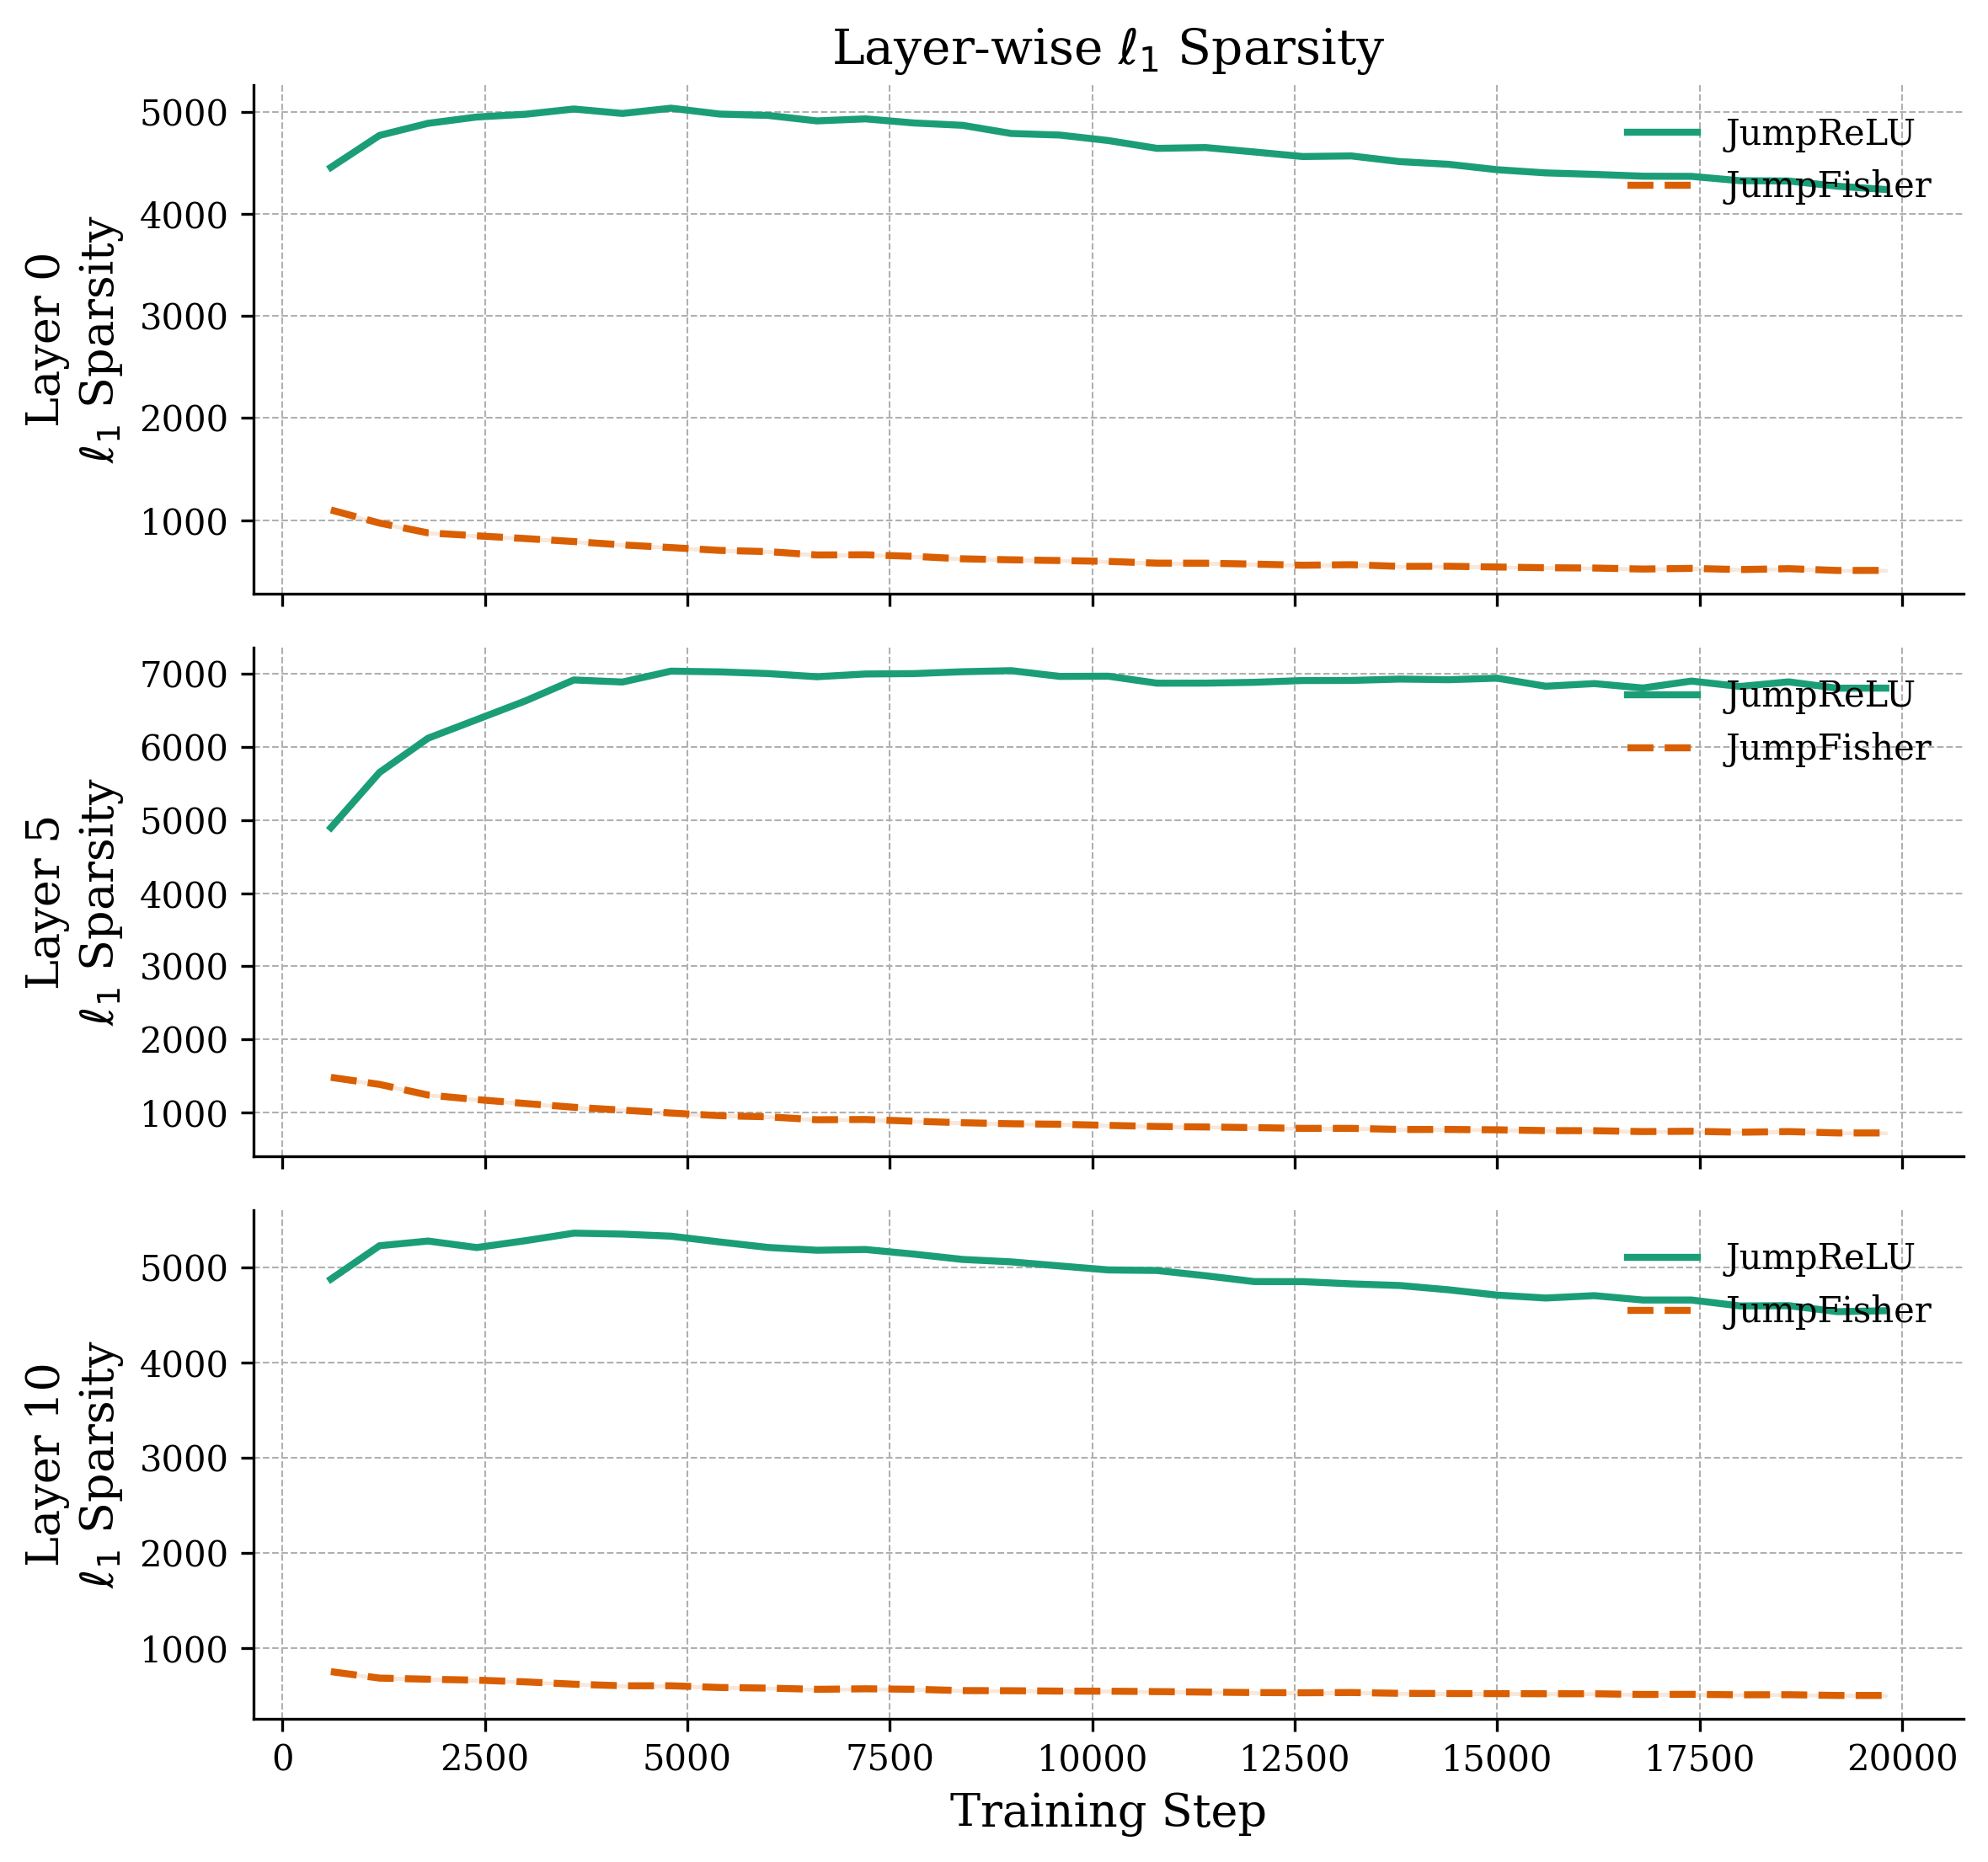

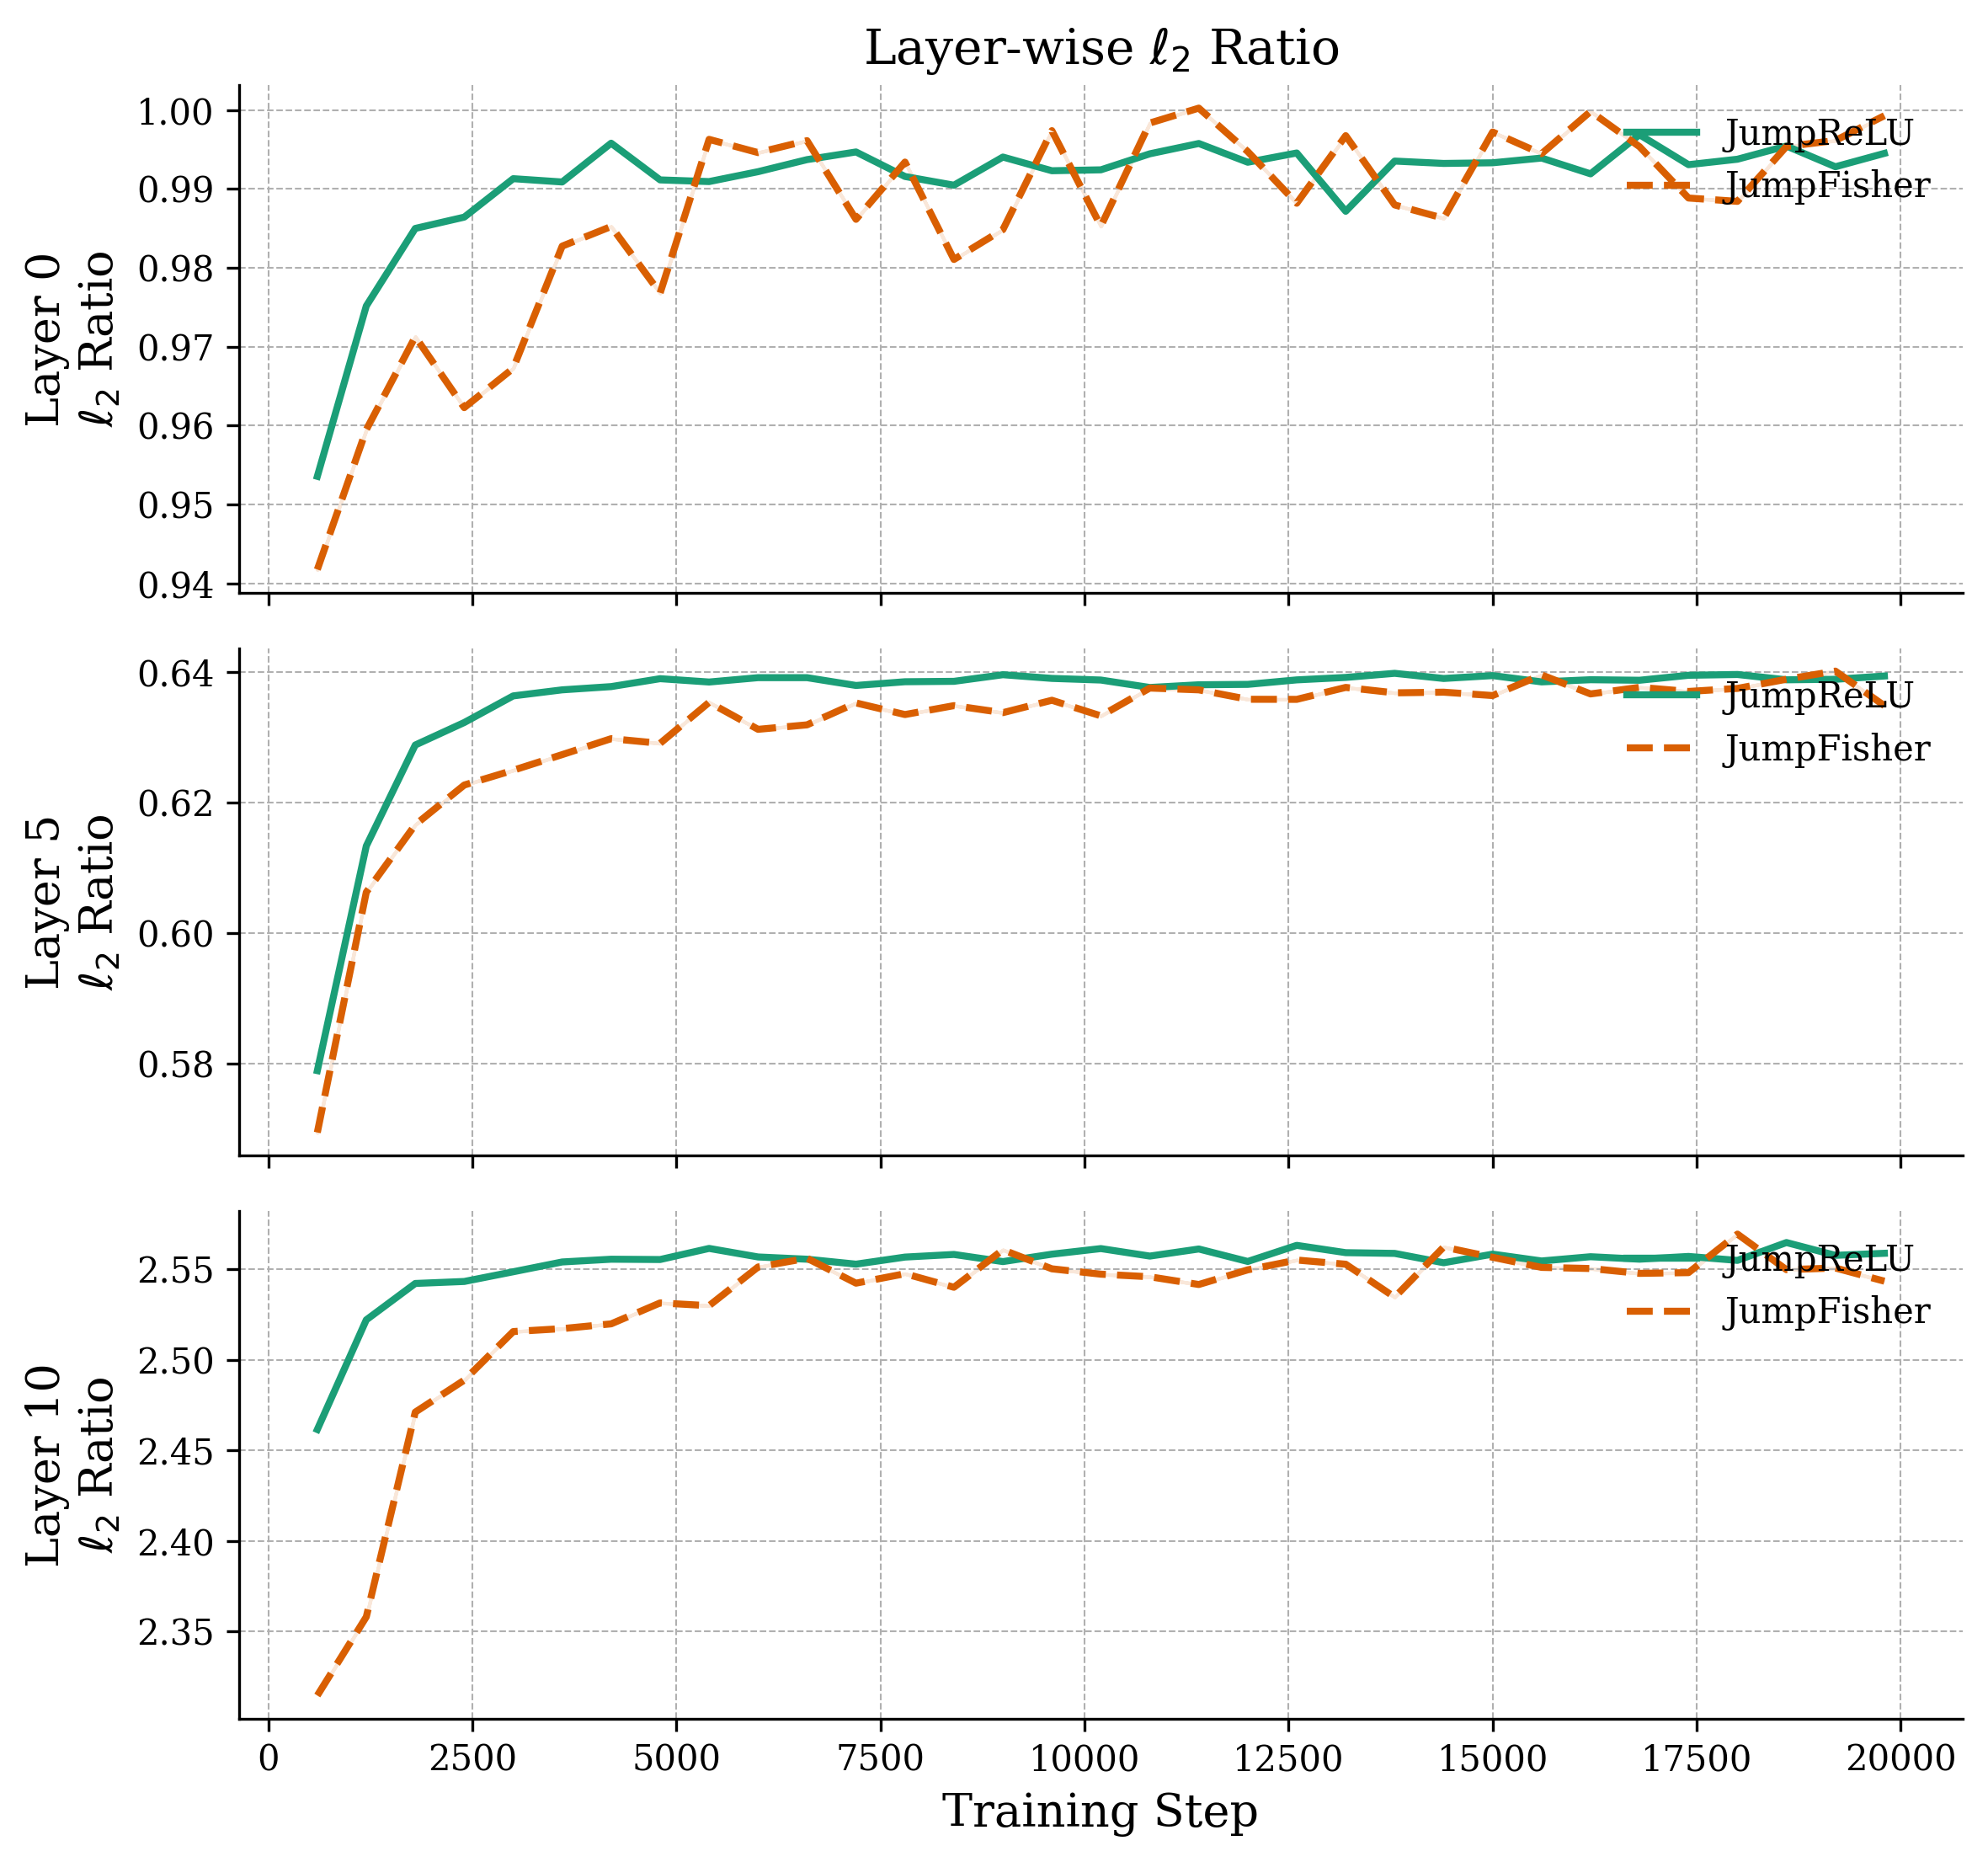

In [ ]:
plot_layer_metrics(
    file_path='devign_gpt2_mlp/mlp_gpt_l0_sparsity.csv',
    layers=[0, 5, 10],
    metrics=['jumprelu', 'singular_fisher'],
    metric_labels={'jumprelu': 'JumpReLU', 'singular_fisher': 'JumpFisher'},
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    column_template="layer{layer}_mlp_gpt2_{metric} - sparsity.l0",
    output_file='l0_sparsity_plot.pdf'
)

plot_layer_metrics(
    file_path='devign_gpt2_mlp/mlp_gpt_l1_sparsity.csv',
    layers=[0, 5, 10],
    metrics=['jumprelu', 'singular_fisher'],
    metric_labels={'jumprelu': 'JumpReLU', 'singular_fisher': 'JumpFisher'},
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    column_template="layer{layer}_mlp_gpt2_{metric} - sparsity.l1",
    output_file='l1_sparsity_plot.pdf'
)

plot_layer_metrics(
    file_path='devign_gpt2_mlp/mlp_gpt_l2_ratio.csv',
    layers=[0, 5, 10],
    metrics=['jumprelu', 'singular_fisher'],
    metric_labels={'jumprelu': 'JumpReLU', 'singular_fisher': 'JumpFisher'},
    title='Layer-wise $\\ell_2$ Ratio',
    ylabel='$\\ell_2$ Ratio',
    column_template="layer{layer}_mlp_gpt2_{metric} - shrinkage.l2_ratio",
    output_file='l2_ratio_plot.pdf'
)


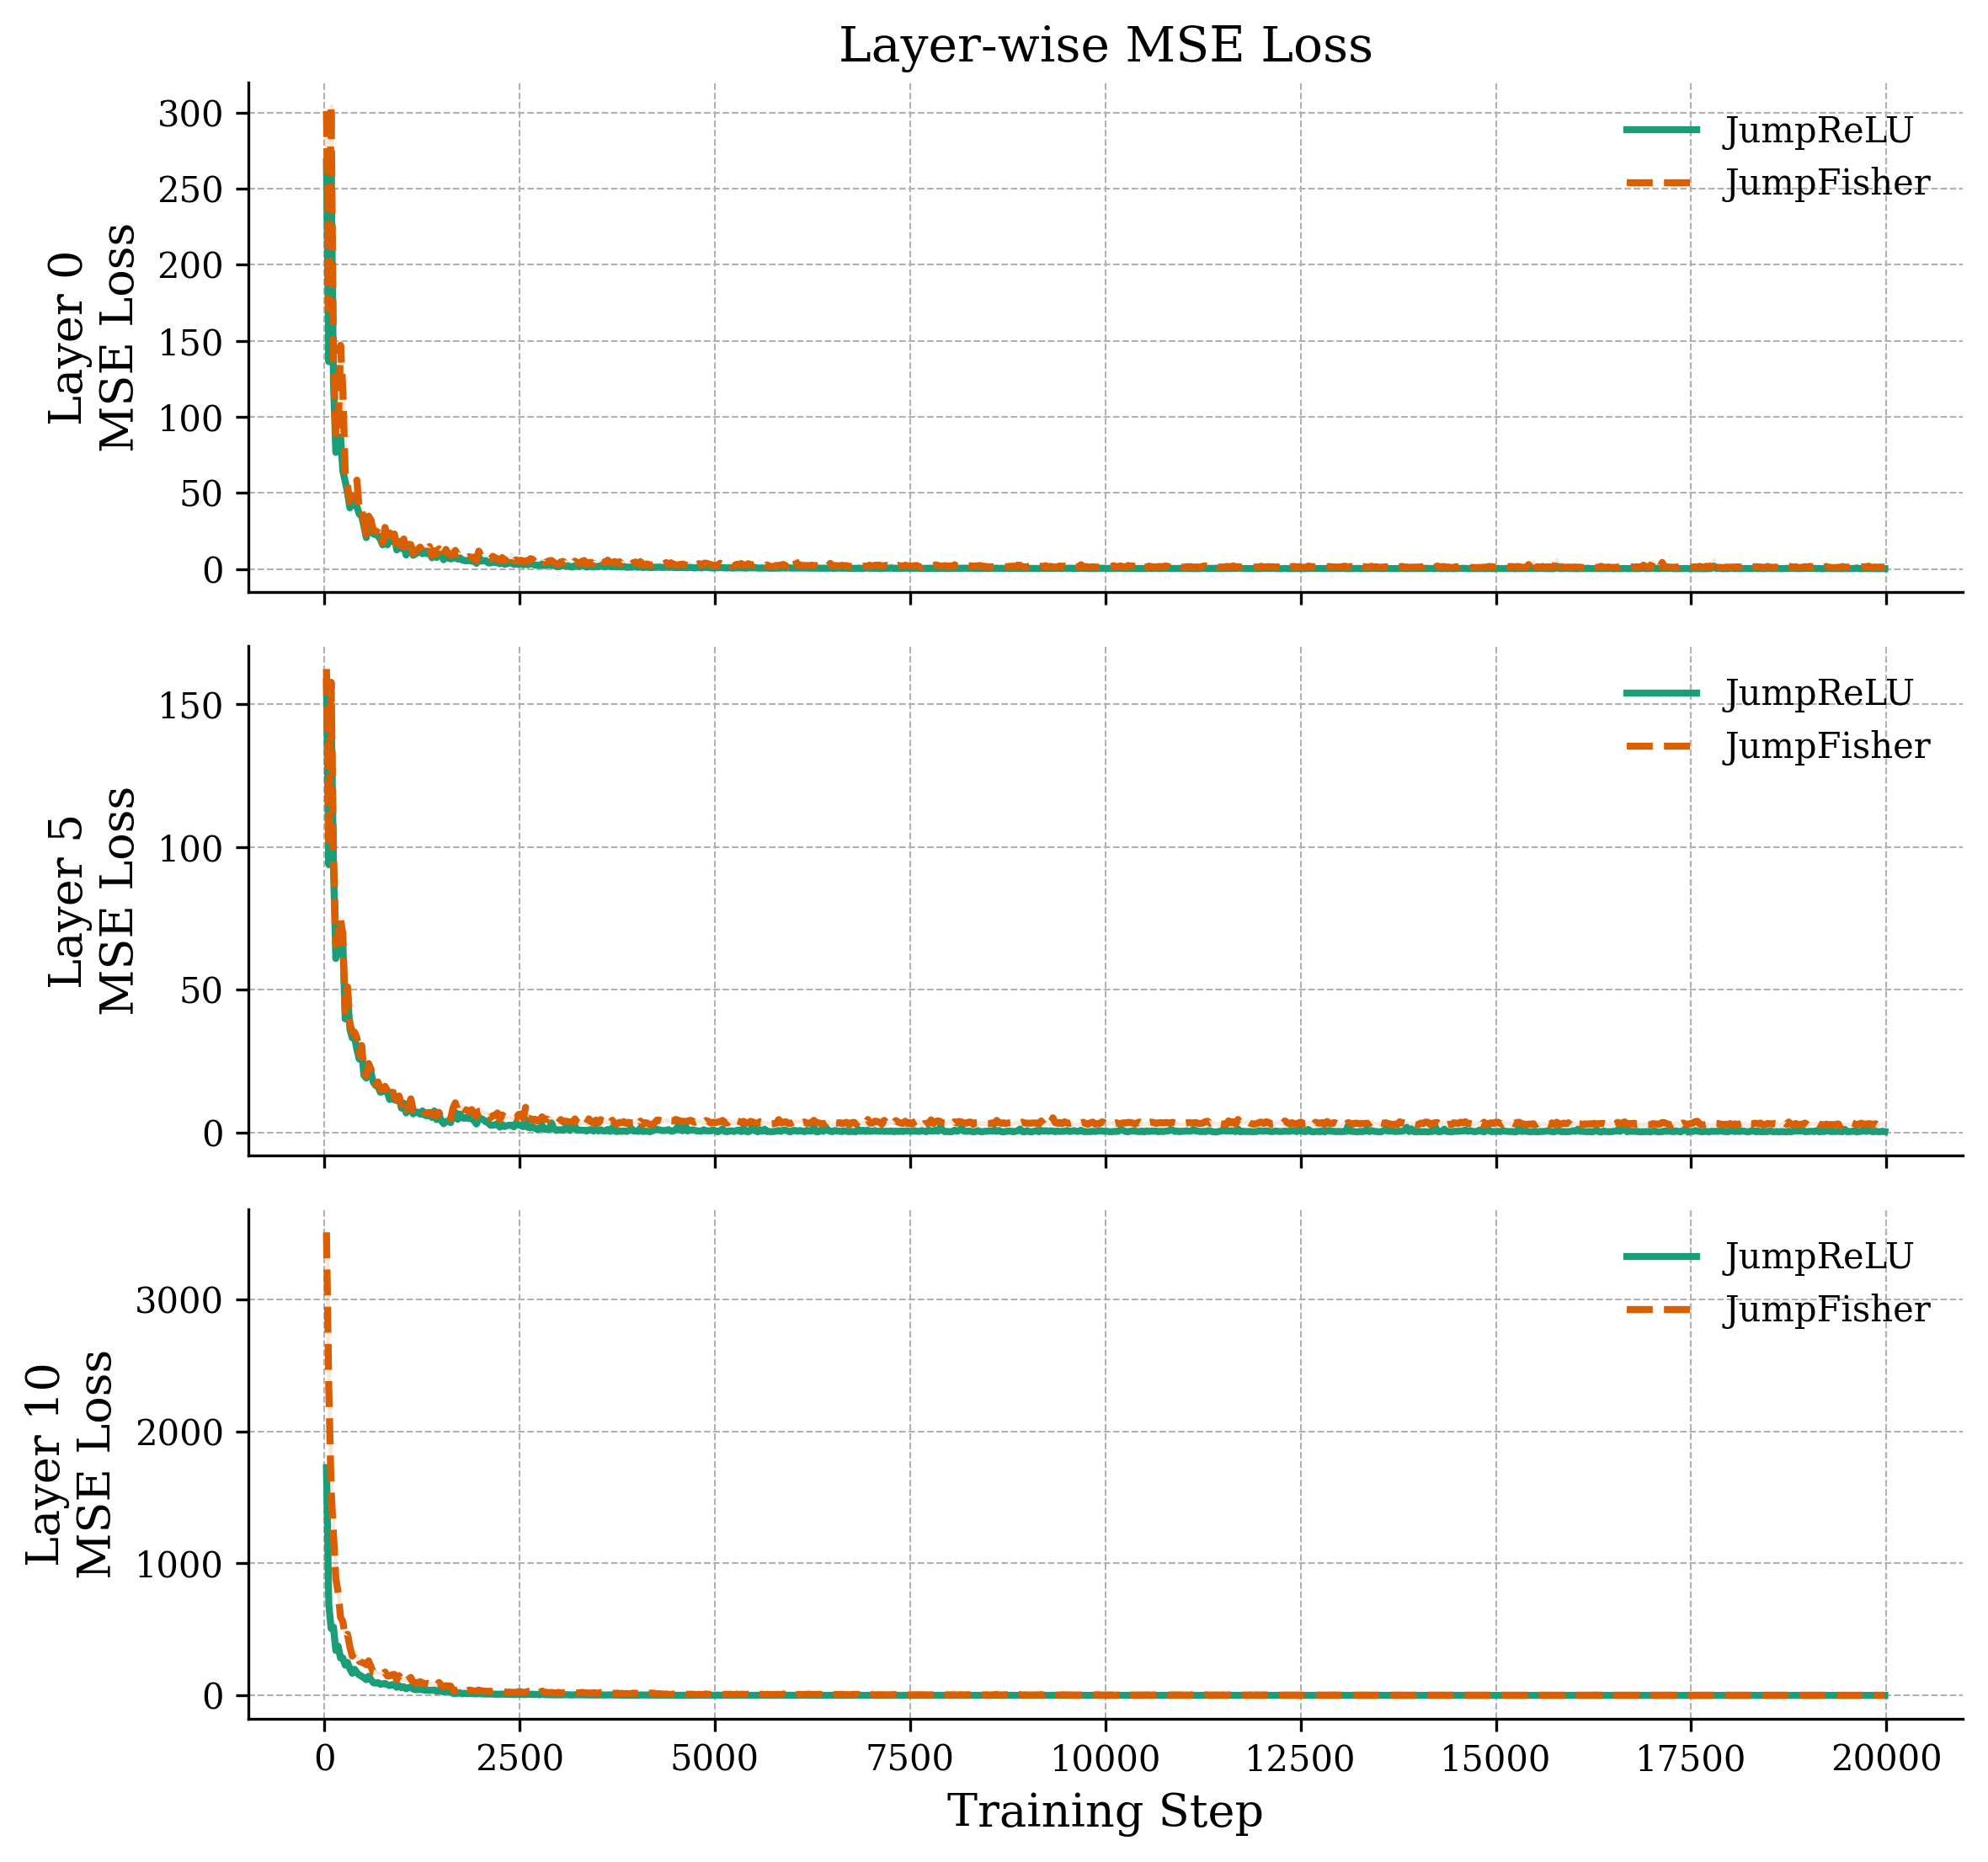

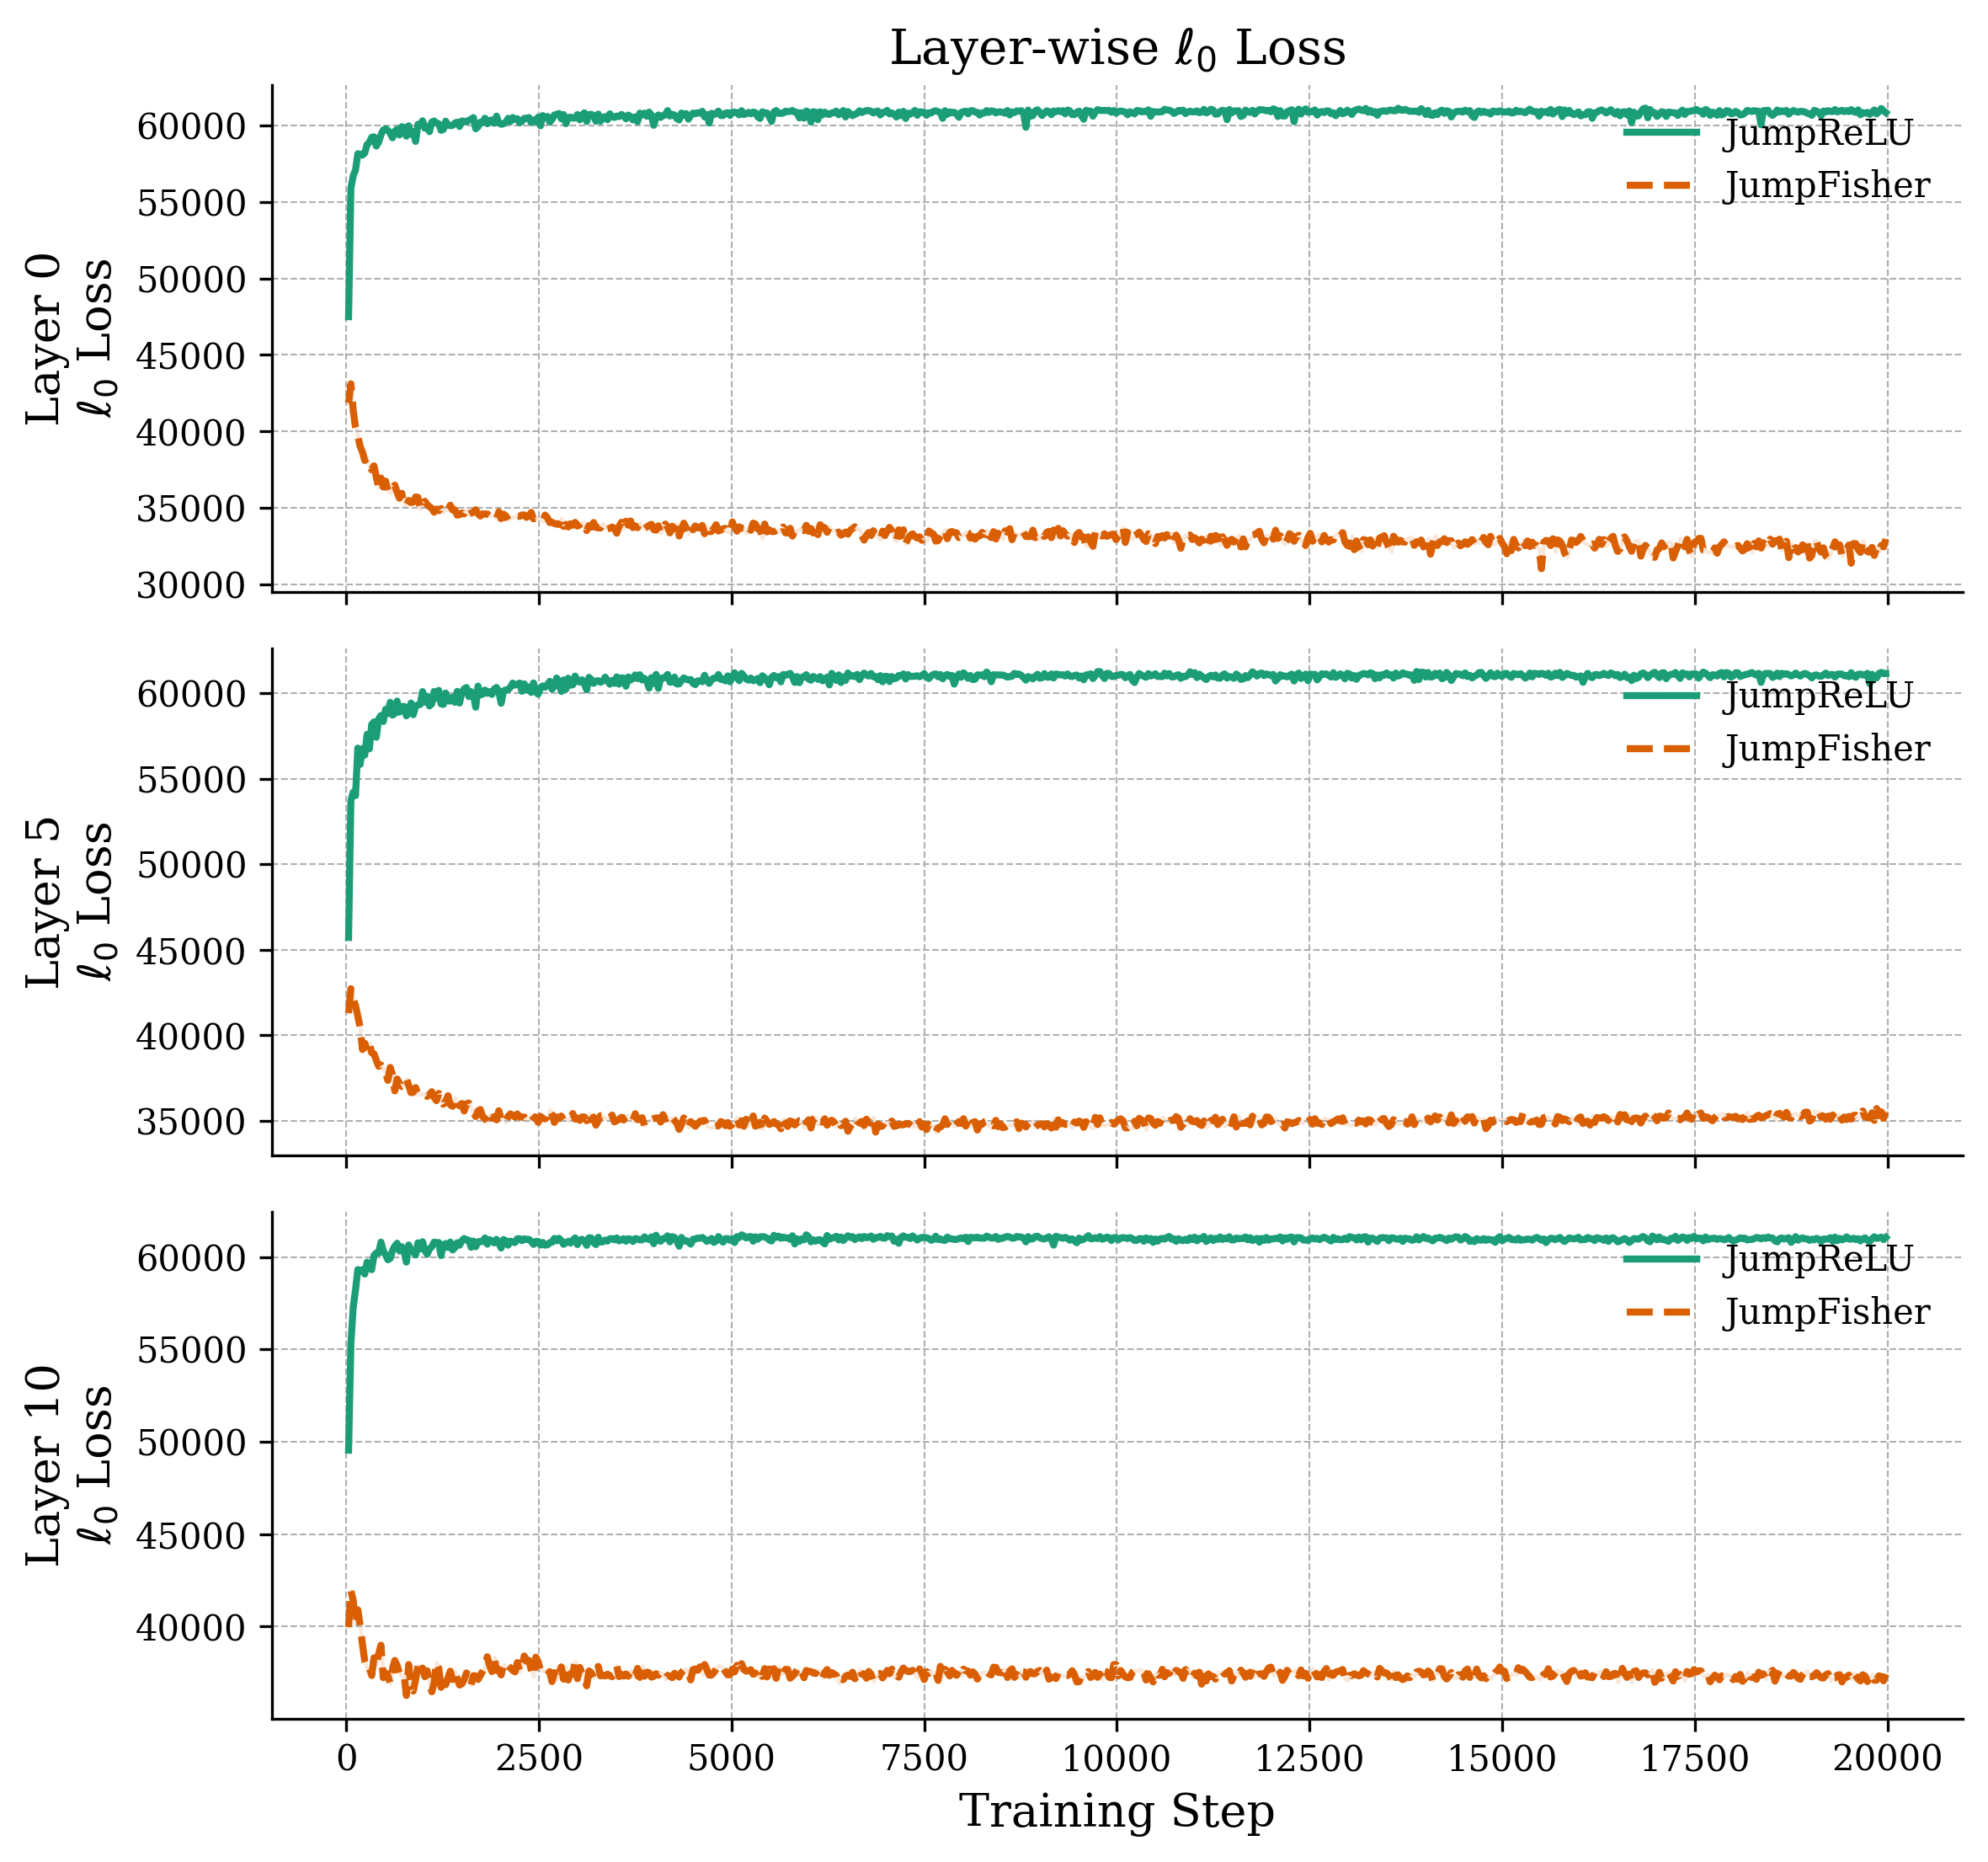

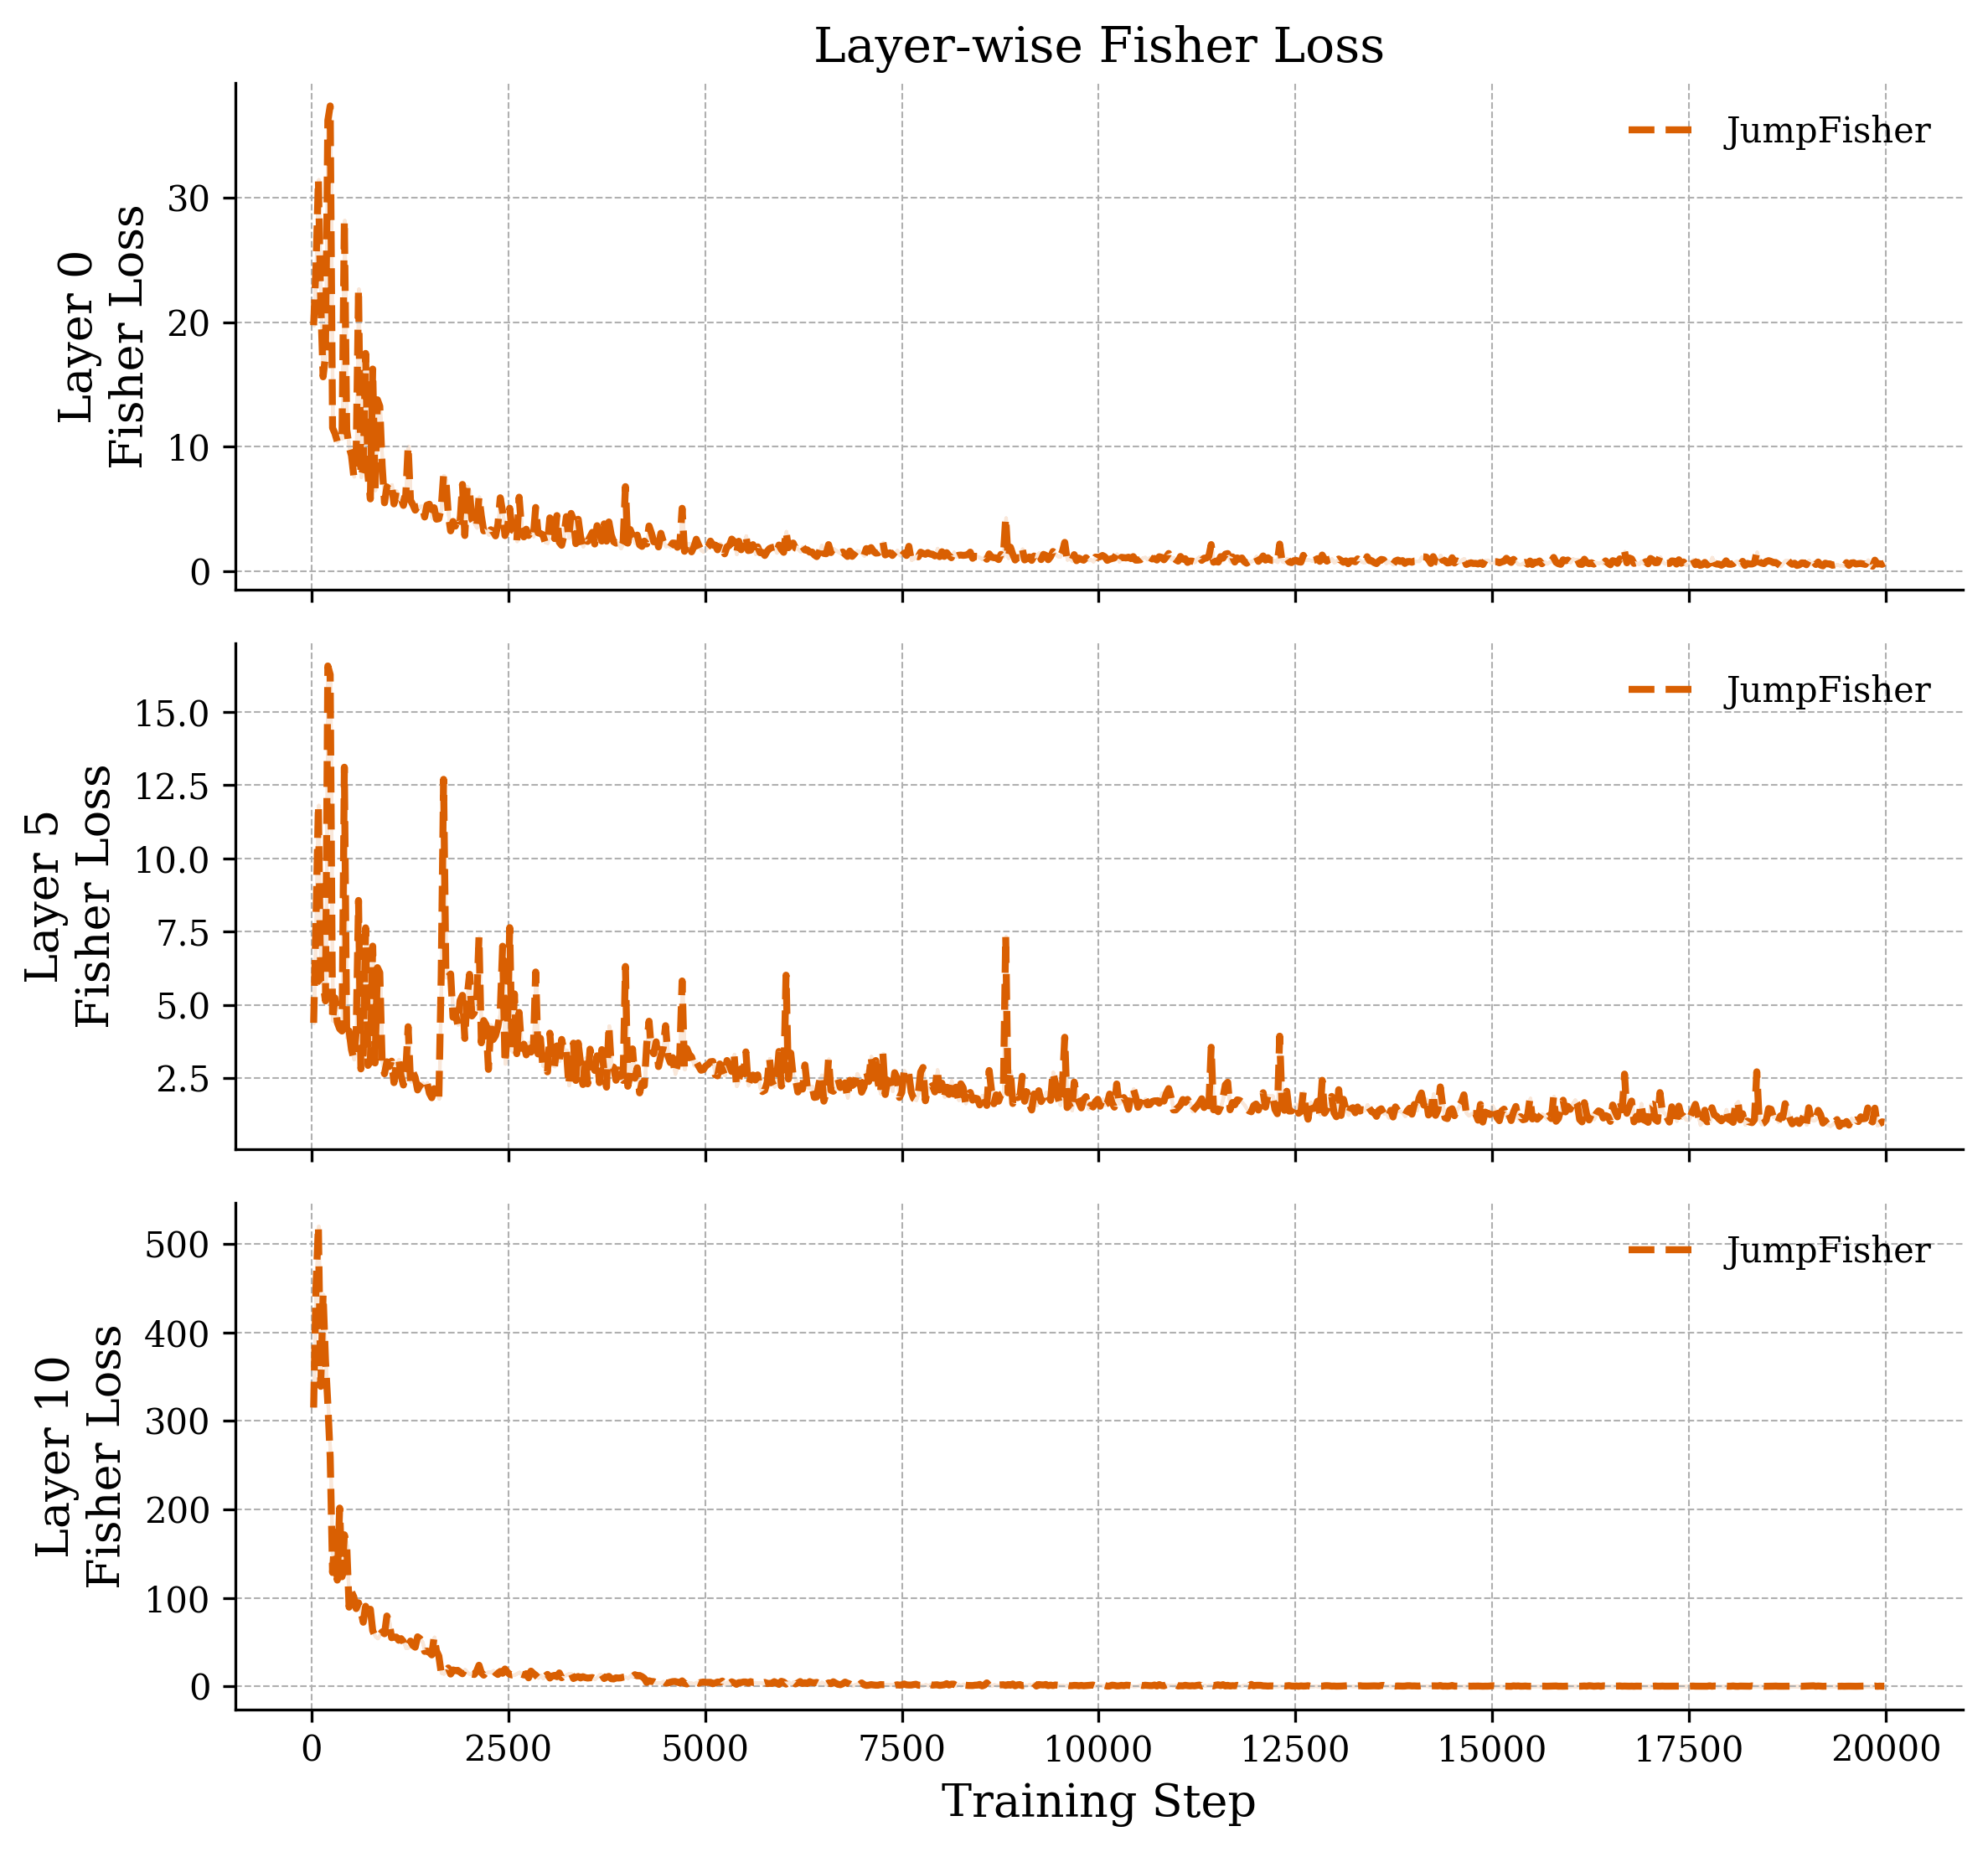

In [ ]:
plot_layer_metrics(
    file_path='devign_gpt2_mlp/mlp_gpt_mse_loss.csv',
    layers=[0, 5, 10],
    metrics=['jumprelu', 'singular_fisher'],
    metric_labels={'jumprelu': 'JumpReLU', 'singular_fisher': 'JumpFisher'},
    title='Layer-wise MSE Loss',
    ylabel='MSE Loss',
    column_template="layer{layer}_mlp_gpt2_{metric} - losses/mse_loss",
    output_file='mse_loss_plot.pdf'
)
plot_layer_metrics(
    file_path='devign_gpt2_mlp/mlp_gpt_l0_loss.csv',
    layers=[0, 5, 10],
    metrics=['jumprelu', 'singular_fisher'],
    metric_labels={'jumprelu': 'JumpReLU', 'singular_fisher': 'JumpFisher'},
    title='Layer-wise $\\ell_0$ Loss',
    ylabel='$\\ell_0$ Loss',
    column_template="layer{layer}_mlp_gpt2_{metric} - losses/l0_loss",
    output_file='l0_loss_plot.pdf'
)
plot_layer_metrics(
    file_path='devign_gpt2_mlp/mlp_gpt_fisher_loss.csv',
    layers=[0, 5, 10],
    metrics=['jumprelu', 'singular_fisher'],
    metric_labels={'jumprelu': 'JumpReLU', 'singular_fisher': 'JumpFisher'},
    title='Layer-wise Fisher Loss',
    ylabel='Fisher Loss',
    column_template="layer{layer}_mlp_gpt2_{metric} - losses/fisher_reg_term",
    output_file='fisher_loss_plot.pdf'
)



## Residual Mid / Devign / GPT2


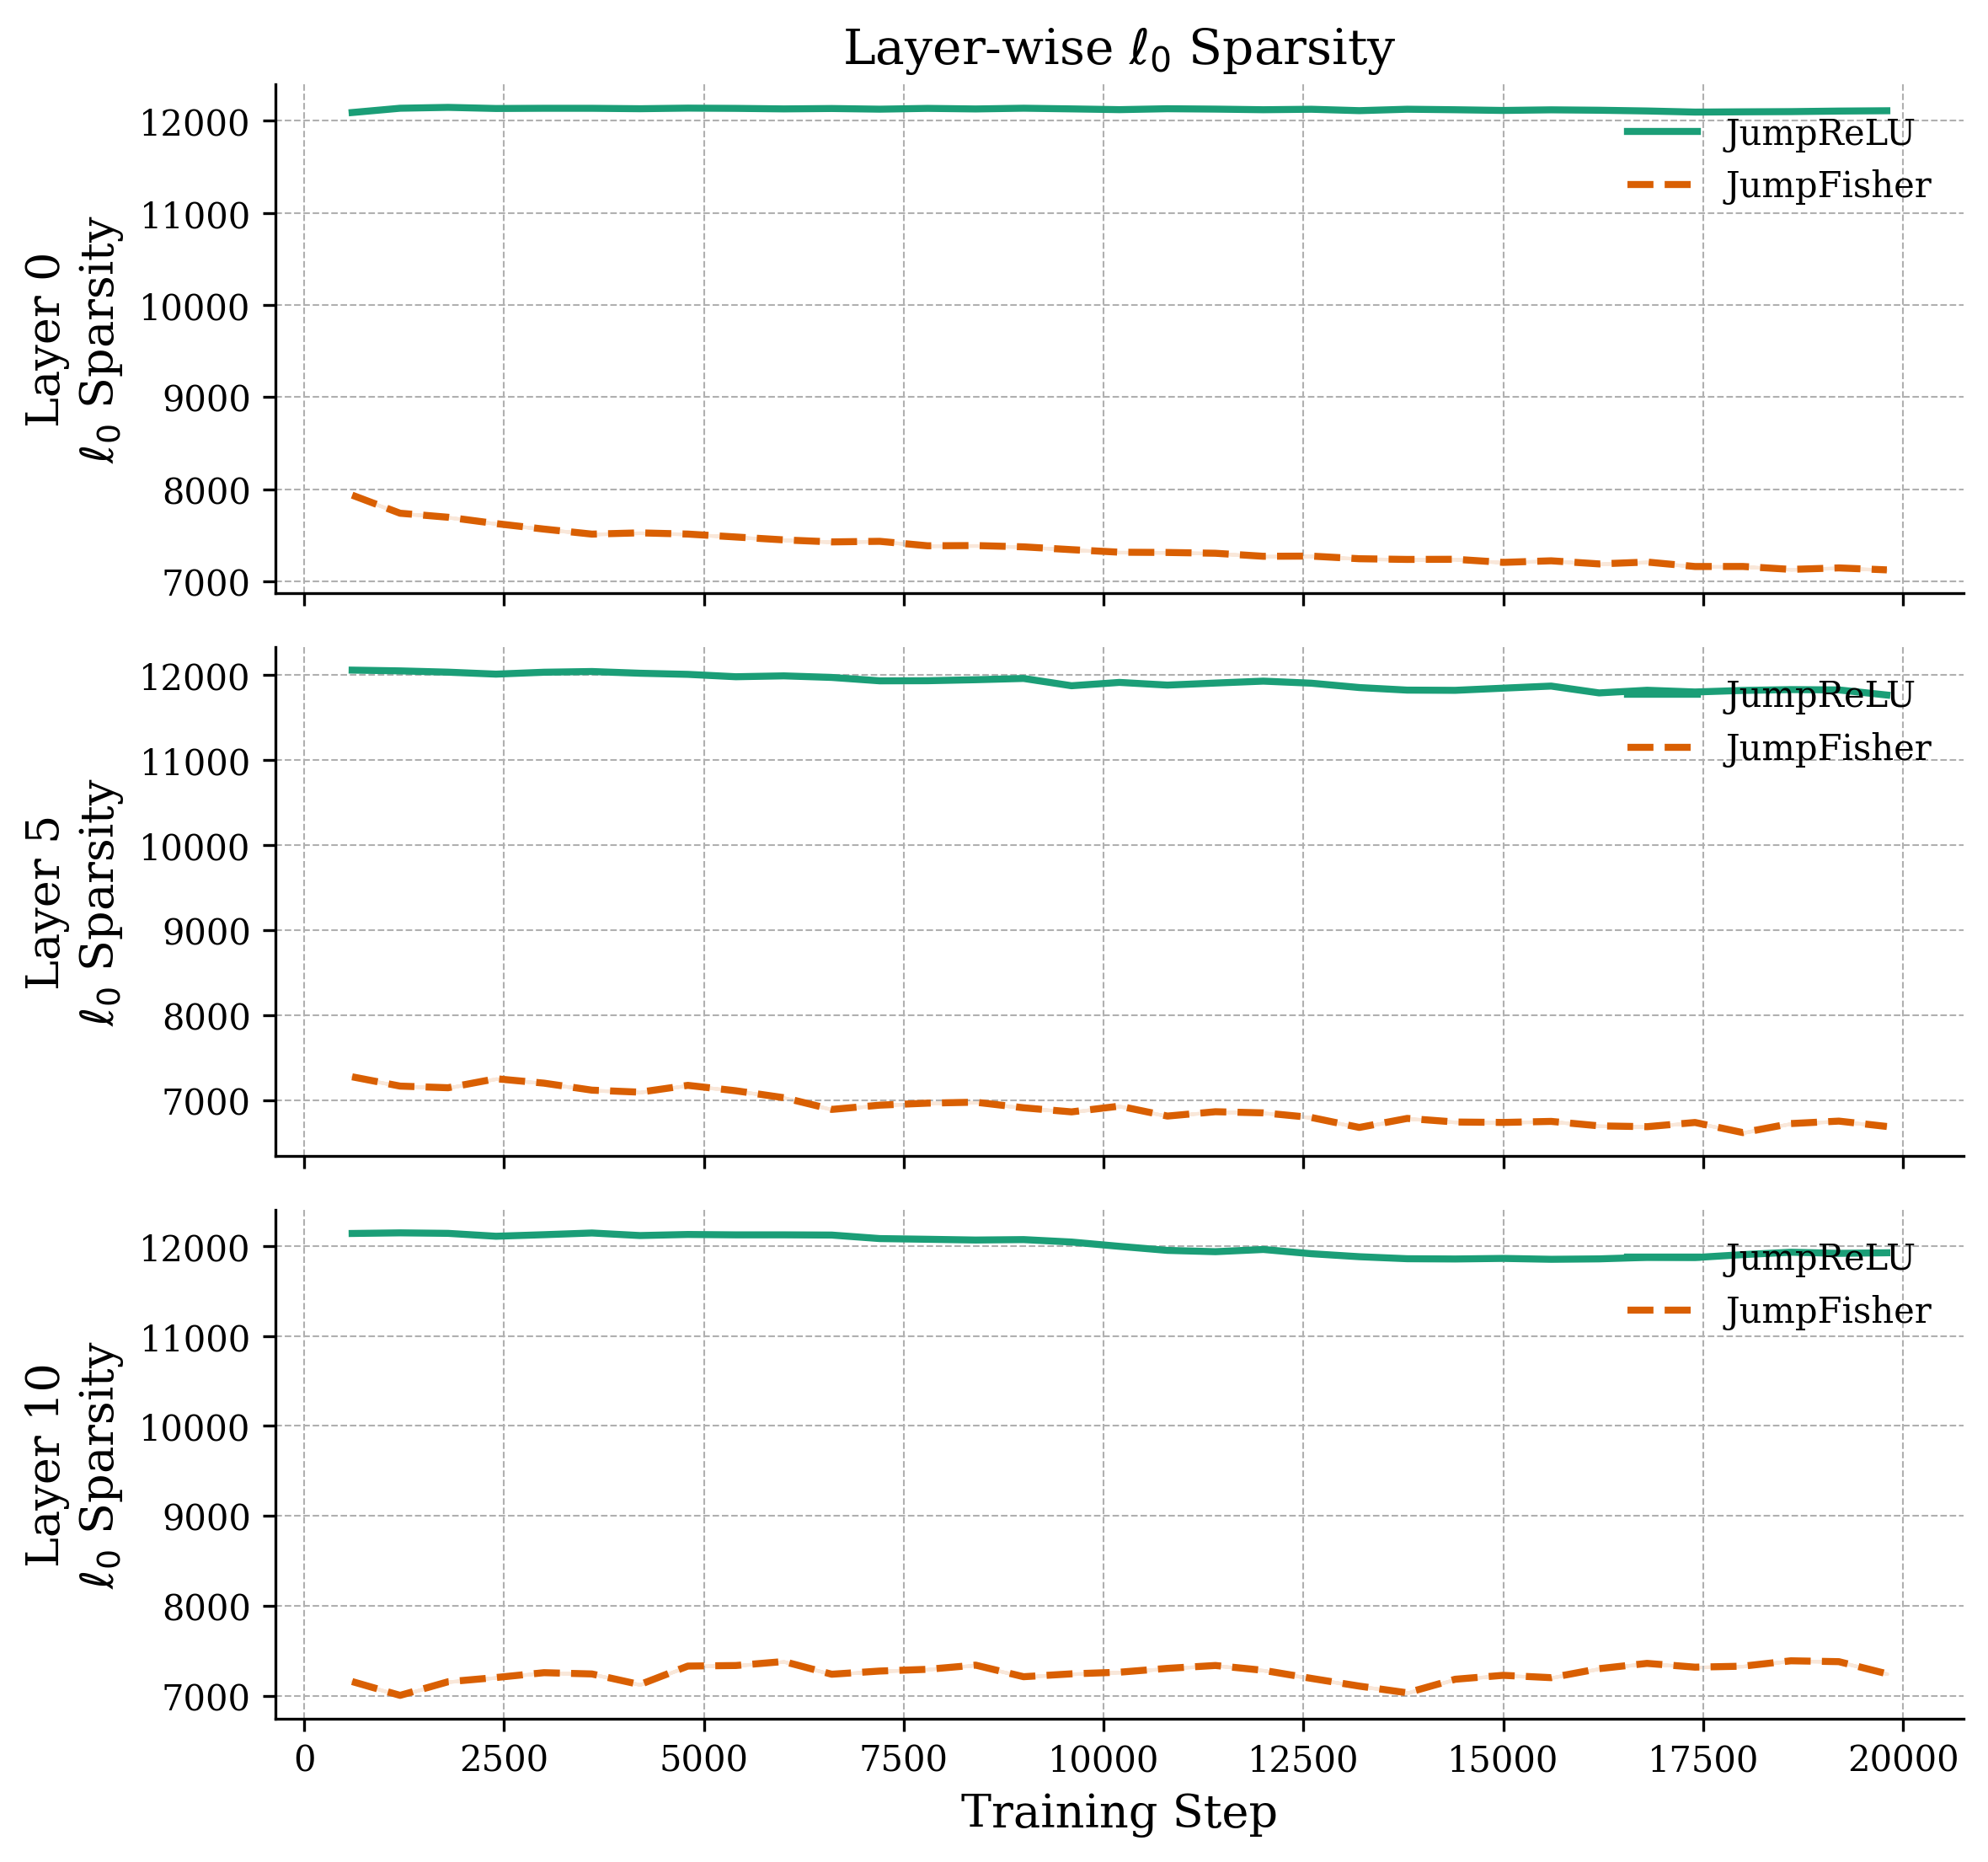

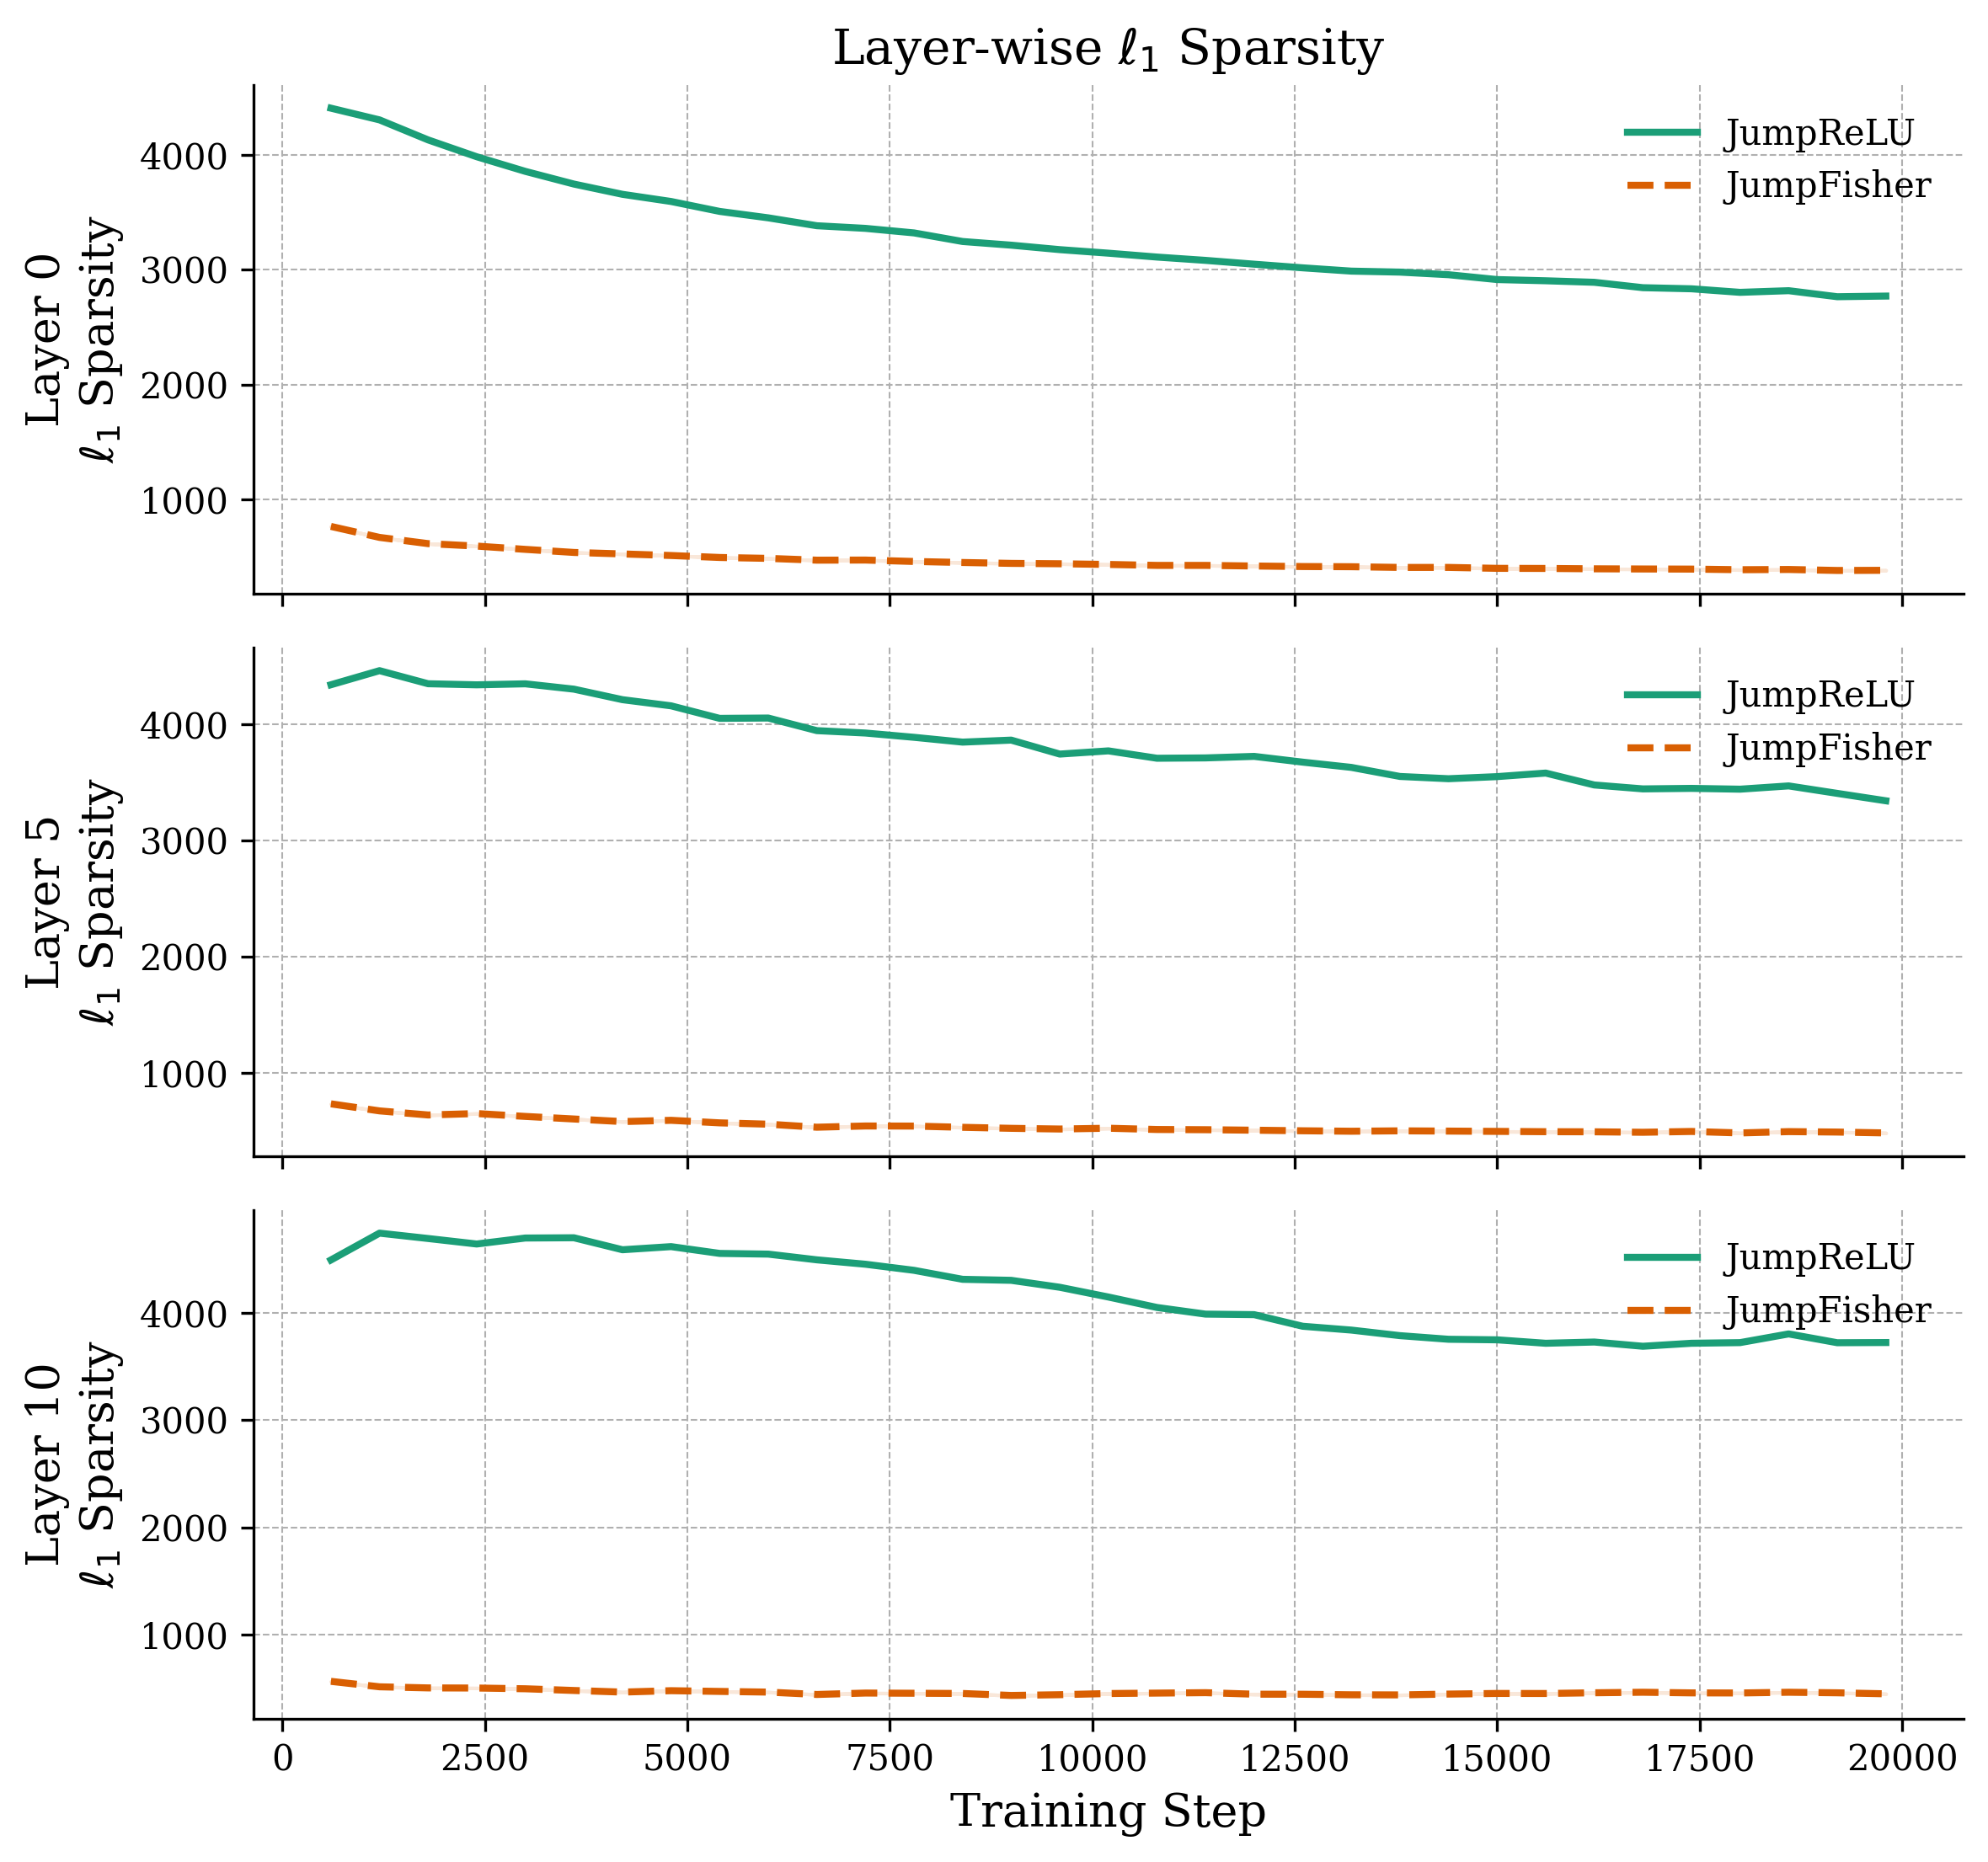

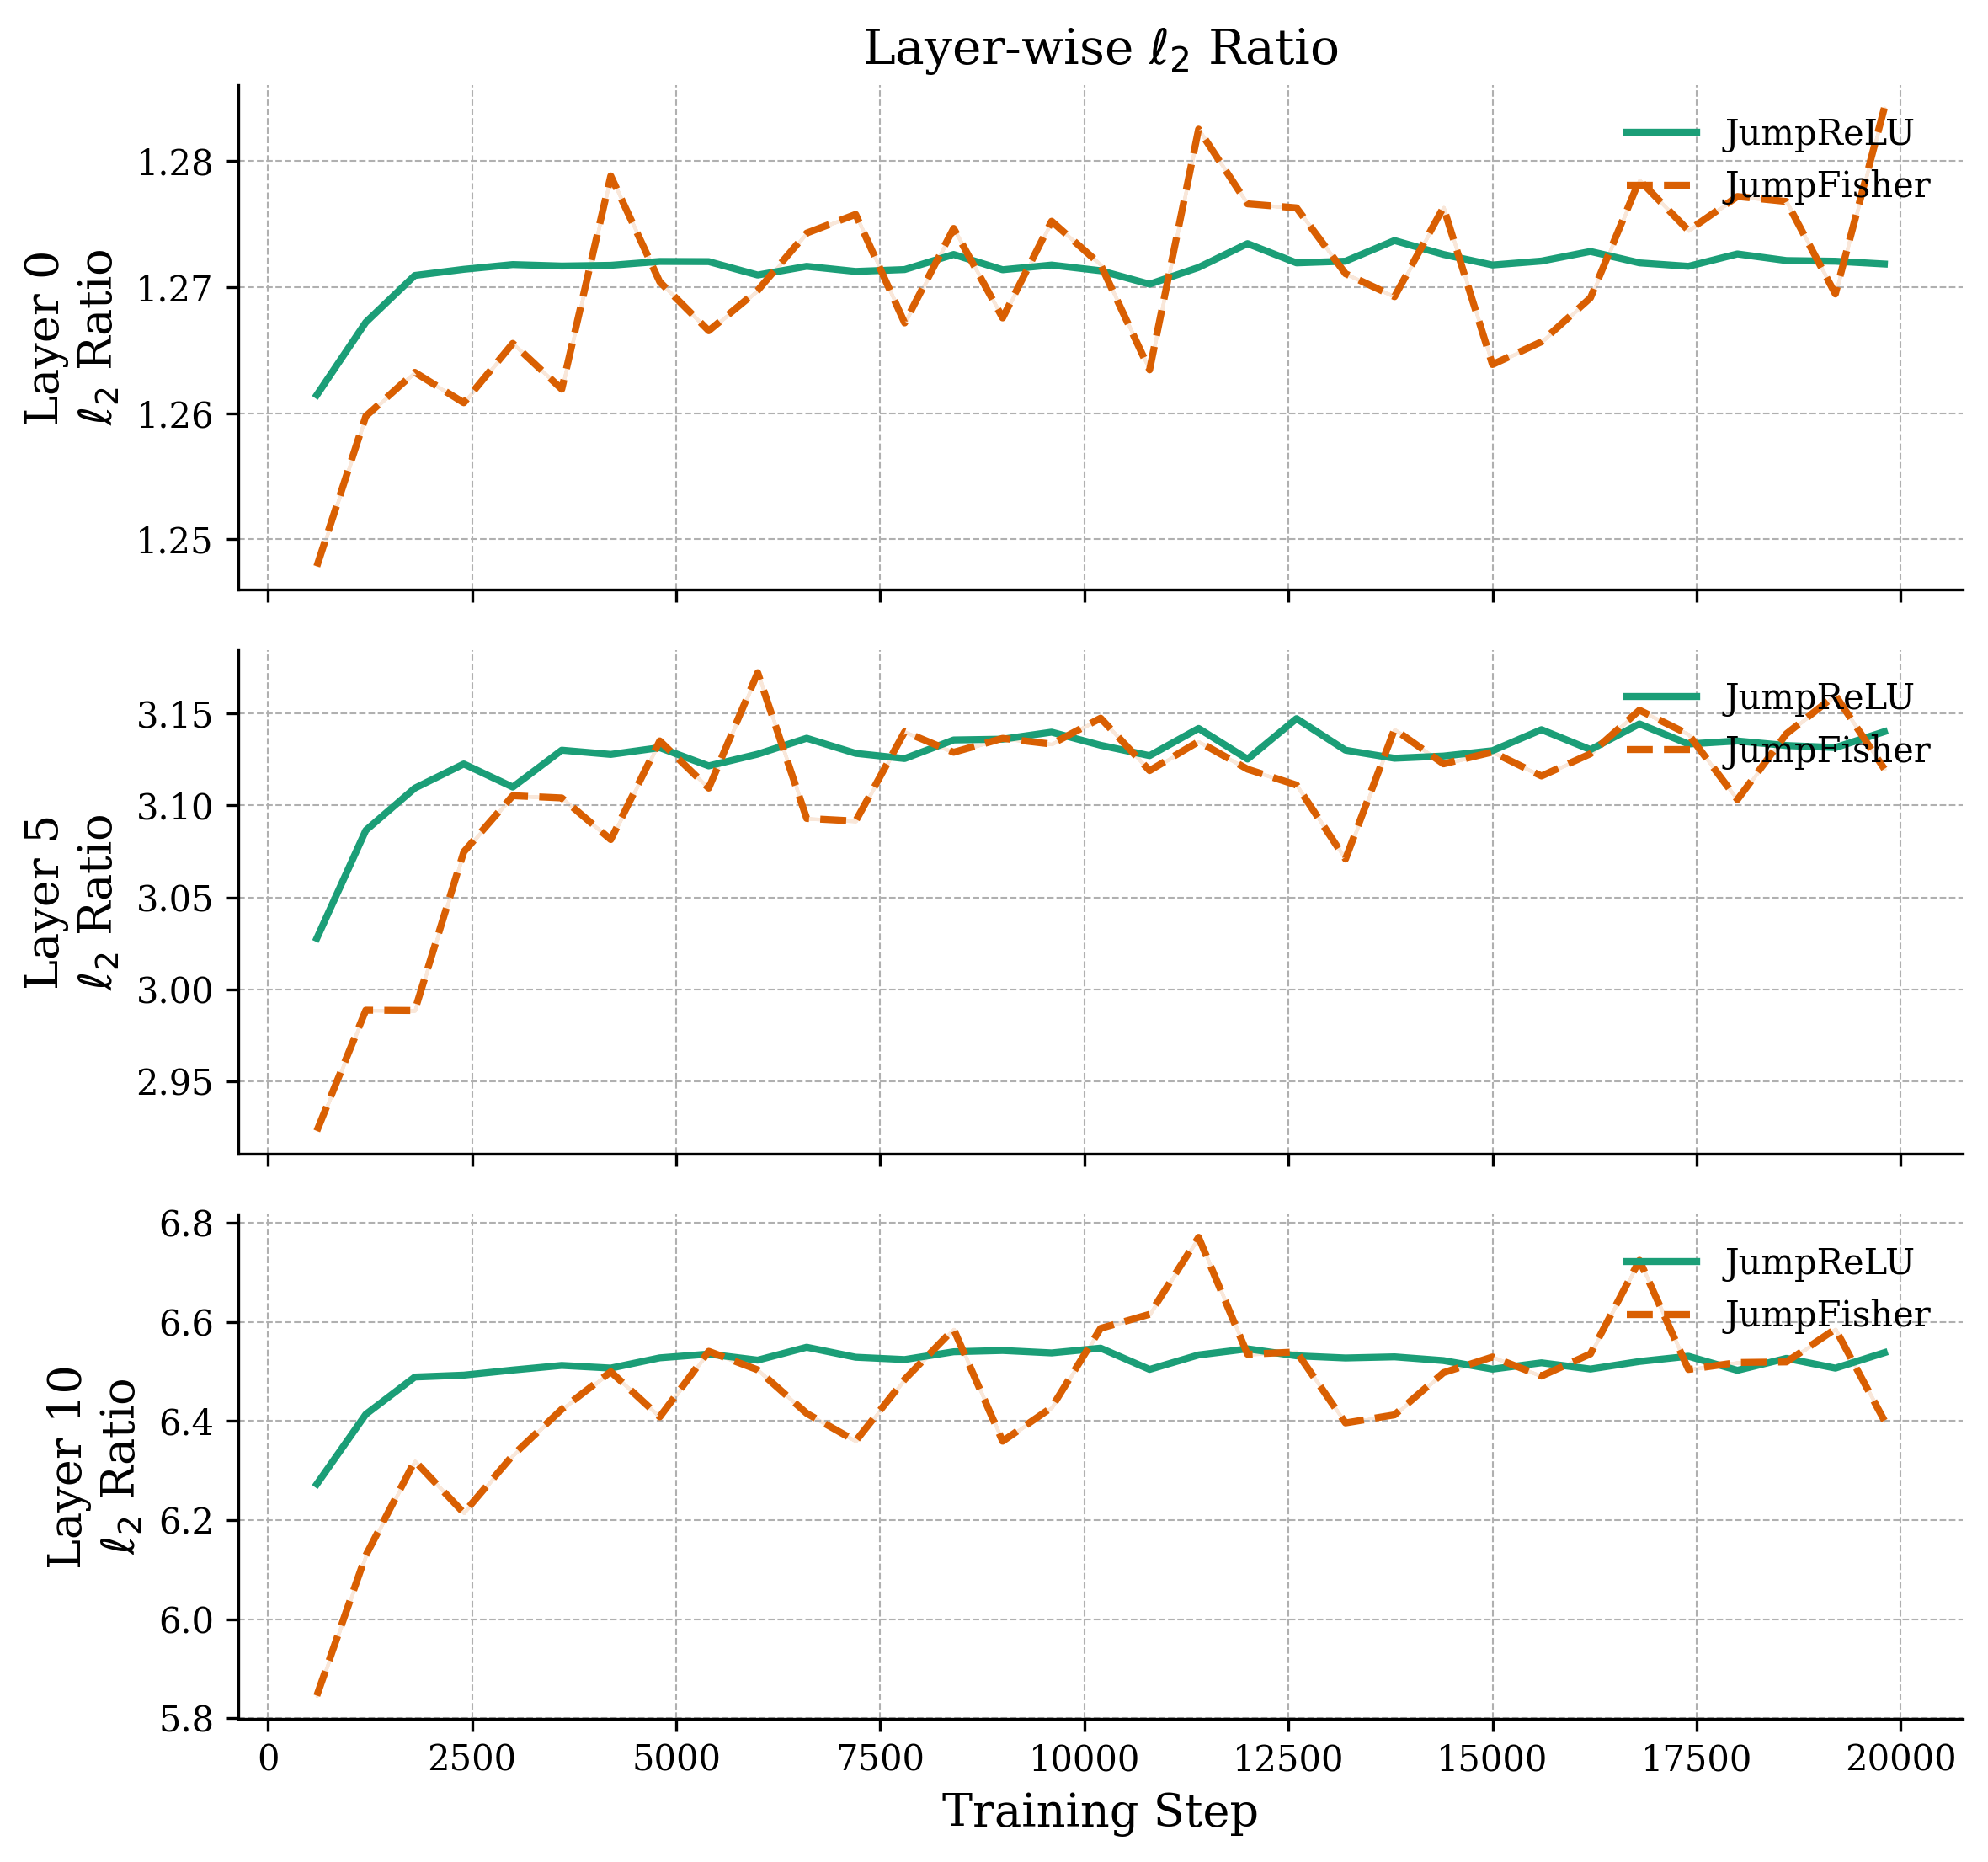

In [38]:
plot_layer_metrics(
    file_path='devign_gpt2_residual_mid/mlp_gpt_l0_sparsity.csv',
    layers=[0, 5, 10],
    metrics=['jumprelu', 'singular_fisher'],
    metric_labels={'jumprelu': 'JumpReLU', 'singular_fisher': 'JumpFisher'},
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    column_template="layer{layer}_residual_mid_gpt2_{metric} - sparsity.l0",
    output_file='devign_gpt2_residual_mid/l0_sparsity_plot.pdf'
)

plot_layer_metrics(
    file_path='devign_gpt2_residual_mid/mlp_gpt_l1_sparsity.csv',
    layers=[0, 5, 10],
    metrics=['jumprelu', 'singular_fisher'],
    metric_labels={'jumprelu': 'JumpReLU', 'singular_fisher': 'JumpFisher'},
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    column_template="layer{layer}_residual_mid_gpt2_{metric} - sparsity.l1",
    output_file='devign_gpt2_residual_mid/l1_sparsity_plot.pdf'
)

plot_layer_metrics(
    file_path='devign_gpt2_residual_mid/mlp_gpt_l2_ratio.csv',
    layers=[0, 5, 10],
    metrics=['jumprelu', 'singular_fisher'],
    metric_labels={'jumprelu': 'JumpReLU', 'singular_fisher': 'JumpFisher'},
    title='Layer-wise $\\ell_2$ Ratio',
    ylabel='$\\ell_2$ Ratio',
    column_template="layer{layer}_residual_mid_gpt2_{metric} - shrinkage.l2_ratio",
    output_file='devign_gpt2_residual_mid/l2_ratio_plot.pdf'
)


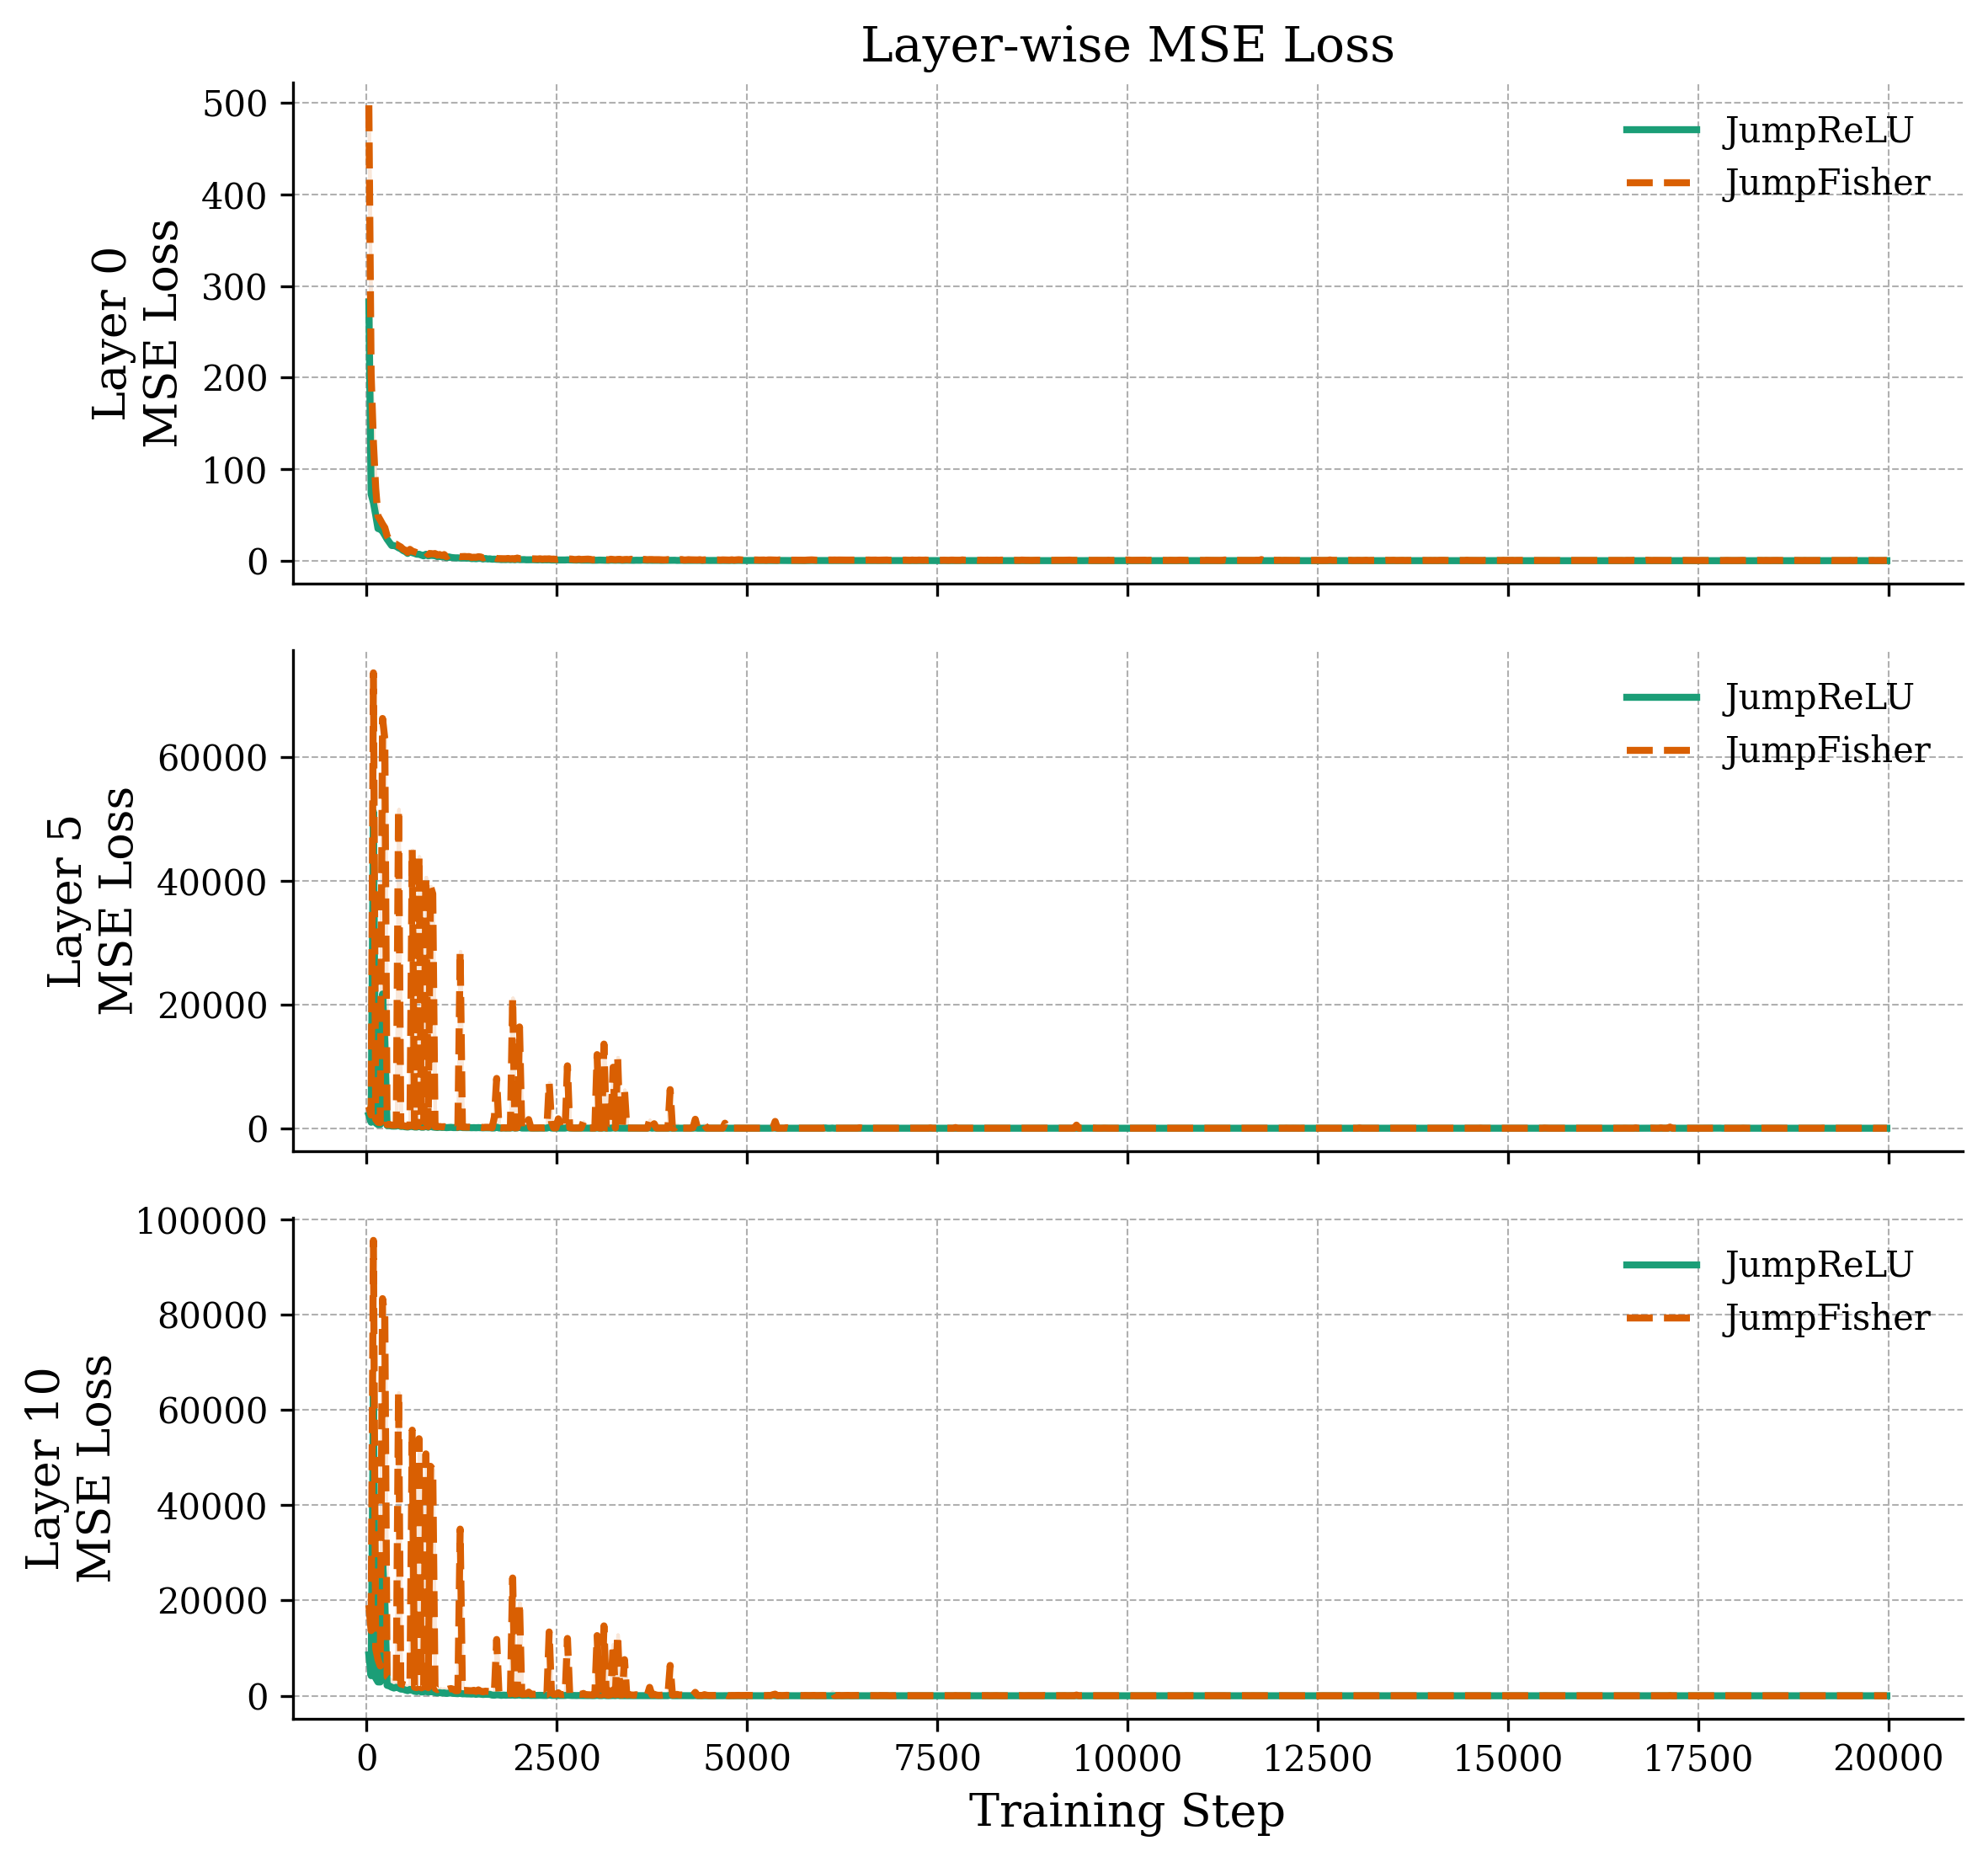

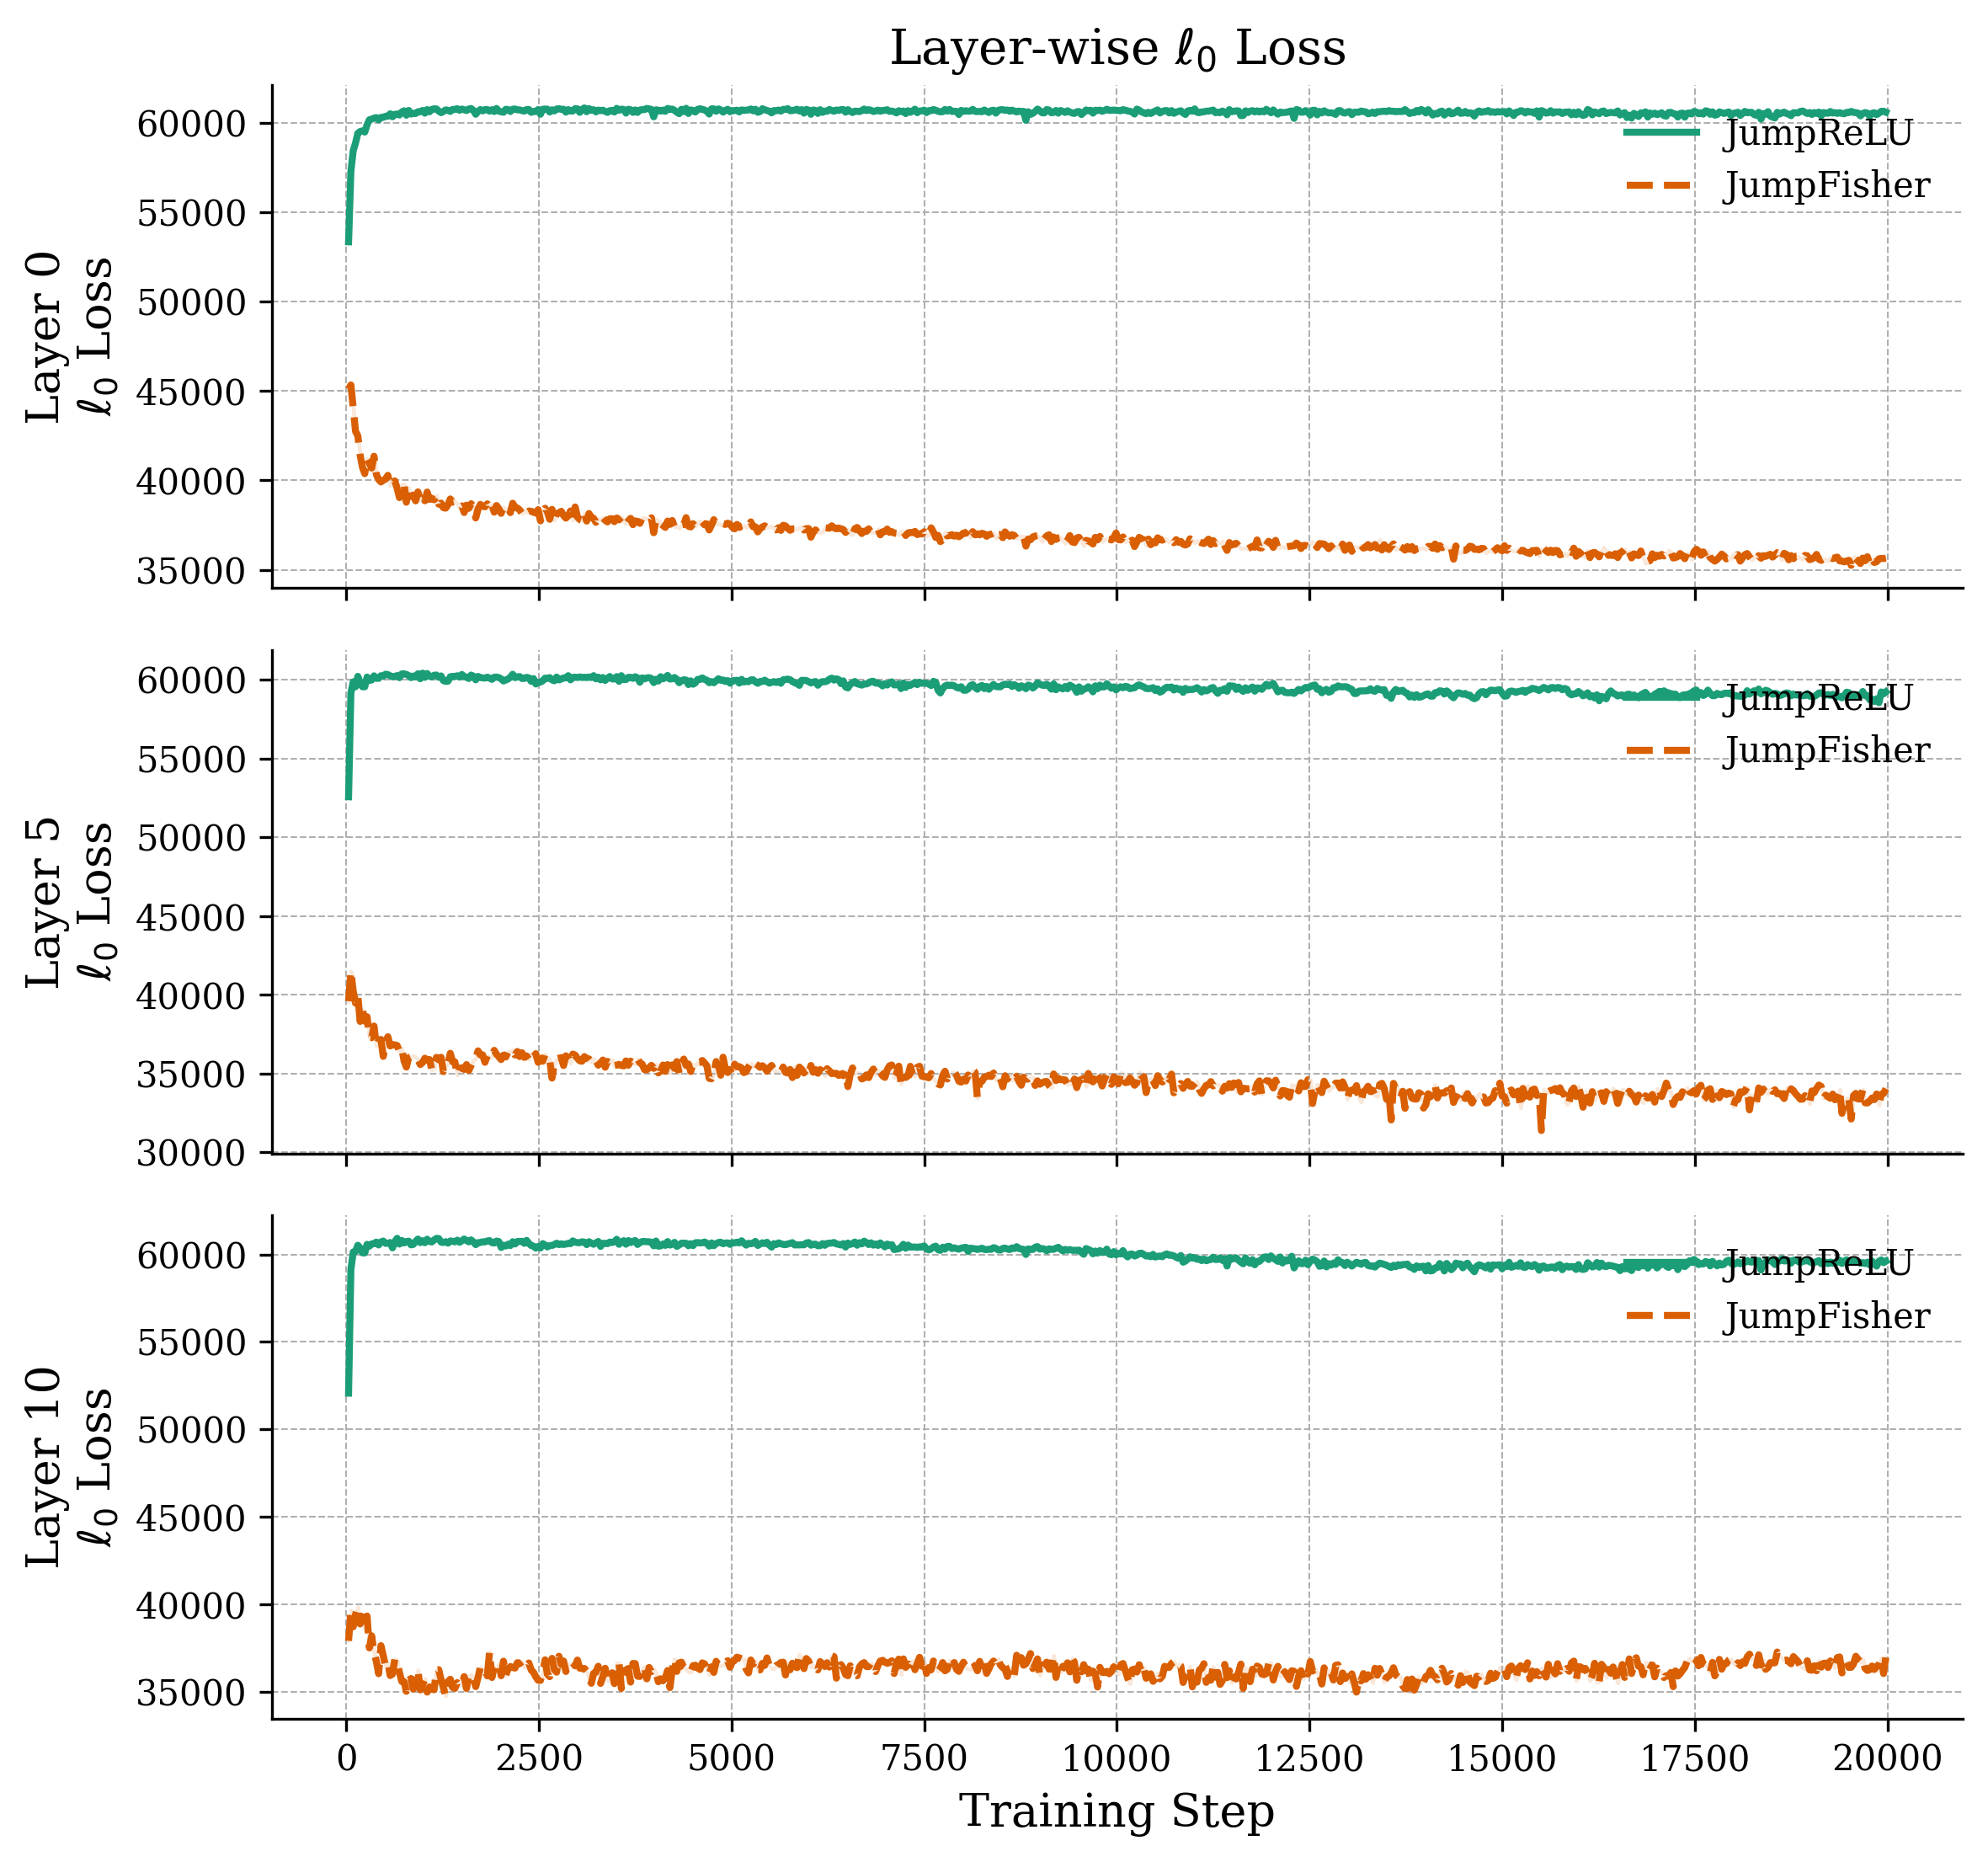

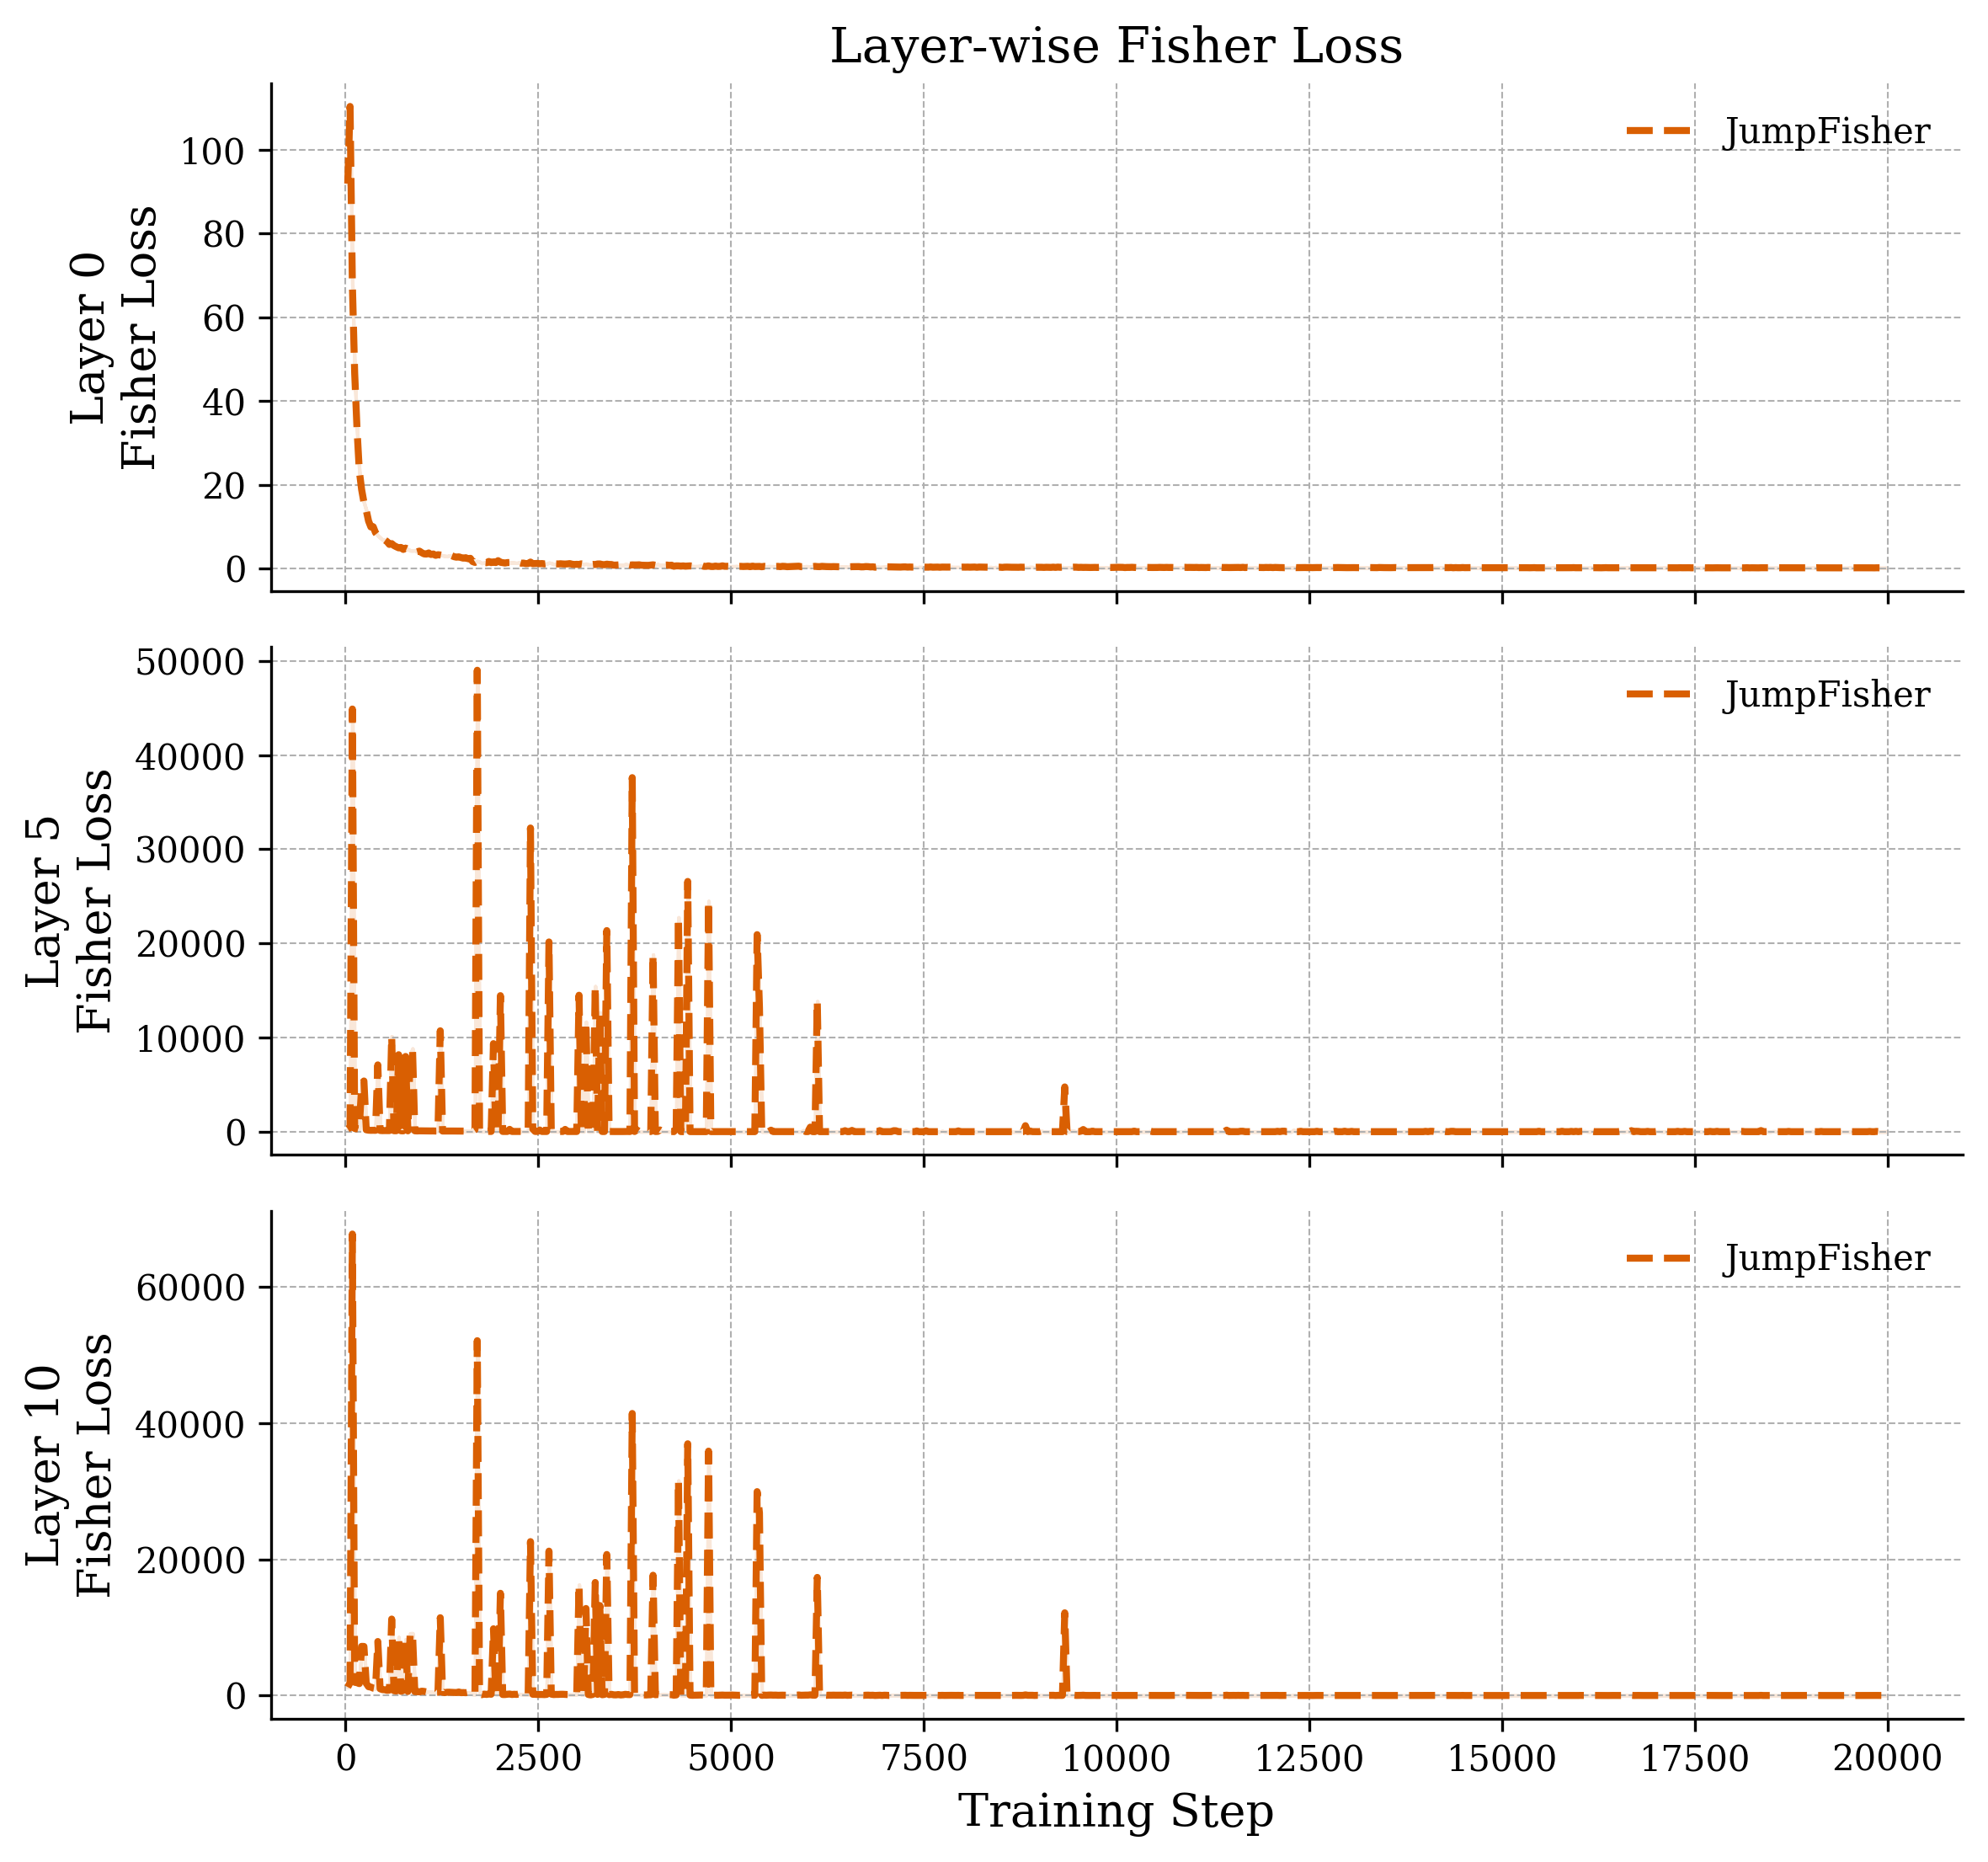

In [39]:
plot_layer_metrics(
    file_path='devign_gpt2_residual_mid/mlp_gpt_mse_loss.csv',
    layers=[0, 5, 10],
    metrics=['jumprelu', 'singular_fisher'],
    metric_labels={'jumprelu': 'JumpReLU', 'singular_fisher': 'JumpFisher'},
    title='Layer-wise MSE Loss',
    ylabel='MSE Loss',
    column_template="layer{layer}_residual_mid_gpt2_{metric} - losses/mse_loss",
    output_file='devign_gpt2_residual_mid/mse_loss_plot.pdf'
)
plot_layer_metrics(
    file_path='devign_gpt2_residual_mid/mlp_gpt_l0_loss.csv',
    layers=[0, 5, 10],
    metrics=['jumprelu', 'singular_fisher'],
    metric_labels={'jumprelu': 'JumpReLU', 'singular_fisher': 'JumpFisher'},
    title='Layer-wise $\\ell_0$ Loss',
    ylabel='$\\ell_0$ Loss',
    column_template="layer{layer}_residual_mid_gpt2_{metric} - losses/l0_loss",
    output_file='devign_gpt2_residual_mid/l0_loss_plot.pdf'
)
plot_layer_metrics(
    file_path='devign_gpt2_residual_mid/mlp_gpt_fisher_loss.csv',
    layers=[0, 5, 10],
    metrics=['jumprelu', 'singular_fisher'],
    metric_labels={'jumprelu': 'JumpReLU', 'singular_fisher': 'JumpFisher'},
    title='Layer-wise Fisher Loss',
    ylabel='Fisher Loss',
    column_template="layer{layer}_residual_mid_gpt2_{metric} - losses/fisher_reg_term",
    output_file='devign_gpt2_residual_mid/fisher_loss_plot.pdf'
)

